# Imports and Drive Mounting

The code below is used to mount the drive and import the specific libraries to be used like pandas, matplotlob, etc.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import math

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Data Preprocessing

## DOH Covid-19 Data Drop

- Source: Open Data Philippines (COVID-19 DOH Data Drop (November 26, 2022))

- Link: https://data.gov.ph/index/public/dataset/covid-19-doh-data-drop-(november-26,-2022)/vuo95enr-tttu-24cu-3x70-agzd8kcvhkop

- Collection Method: The files were downloaded from Open Data Philippines. 5 CSV files were downloaded containing case informations of those who contracted the virus.

### Reading the DOH Covid-19 Data Drop Files

To start, the csv files will be read sequencially and be concatenated together. It is because the case information is separated into 5 files. `on_bad_lines` ensures that no bad rows gets included in the read.

In [2]:
cases_path = "/content/drive/MyDrive/cases"
df_arr = []

for x in range(5):
  df_arr.append(pd.read_csv(cases_path + "/case_batch_" + str(x) + ".csv", on_bad_lines='skip'))

df = pd.concat(df_arr, ignore_index=True)

df

/tmp/ipython-input-706804424.py:5: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_arr.append(pd.read_csv(cases_path + "/case_batch_" + str(x) + ".csv", on_bad_lines='skip'))


,CaseCode,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,...,ProvRes,CityMunRes,CityMuniPSGC,BarangayRes,BarangayPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
0,C404174,38.0,35 to 39,FEMALE,NaN,2020-01-30,2020-01-30,NaN,NaN,RECOVERED,...,NEGROS ORIENTAL,DUMAGUETE CITY (CAPITAL),PH074610000,NaN,NaN,RECOVERED,NO,2020-01-21,NO,"Removal Type is ""Recovered"", but no Recovered ..."
1,C462688,44.0,40 to 44,MALE,NaN,2020-01-30,2020-02-03,2020-02-01,NaN,DIED,...,NEGROS ORIENTAL,DUMAGUETE CITY (CAPITAL),PH074610000,NaN,NaN,DIED,NO,2020-01-18,NaN,NaN
2,C387710,60.0,60 to 64,FEMALE,2020-01-23,2020-01-30,2020-02-05,NaN,2020-01-31,RECOVERED,...,BOHOL,PANGLAO,PH071233000,NaN,NaN,RECOVERED,NO,2020-01-21,NO,Case has Admitting Facility but is not Admitte...
3,C498051,63.0,60 to 64,MALE,2020-03-05,NaN,2020-03-06,2020-03-11,NaN,DIED,...,RIZAL,CAINTA,PH045805000,NaN,NaN,DIED,NO,NaN,NaN,"Case has Lab Result, but Result Date is blank\..."
4,C377460,49.0,45 to 49,MALE,NaN,NaN,2020-03-06,NaN,NaN,RECOVERED,...,BATANGAS,SANTO TOMAS,PH041028000,NaN,NaN,RECOVERED,NO,NaN,NaN,"Age or Birthdate is Invalid\nRemoval Type is ""..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4032321,C42125481,62.0,60 to 64,FEMALE,2022-11-22,2022-11-23,2022-11-26,NaN,NaN,NaN,...,NCR,CITY OF MAKATI,PH137602000,WEST REMBO,PH137602032,MILD,NO,NaN,NO,NaN
4032322,C41547419,23.0,20 to 24,MALE,2022-11-23,2022-11-23,2022-11-26,NaN,NaN,NaN,...,NCR,CITY OF MAKATI,PH137602000,POBLACION,PH137602020,MILD,NO,NaN,NaN,NaN
4032323,C79183405,27.0,25 to 29,FEMALE,2022-11-22,2022-11-23,2022-11-26,NaN,NaN,NaN,...,NCR,TAGUIG CITY,PH137607000,CALZADA,PH137607004,MILD,NO,NaN,NO,NaN
4032324,C83603032,58.0,55 to 59,FEMALE,2022-11-23,2022-11-24,2022-11-26,NaN,NaN,NaN,...,CEBU,CEBU CITY (CAPITAL),PH072217000,LABANGON,PH072217040,MILD,NO,2022-11-23,NO,NaN


Currently, there are 4032326 rows and 22 columns, with most columns being of type String (stored as objects).

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032326 entries, 0 to 4032325
Data columns (total 22 columns):
 #   Column             Dtype  
---  ------             -----  
 0   CaseCode           object 
 1   Age                float64
 2   AgeGroup           object 
 3   Sex                object 
 4   DateSpecimen       object 
 5   DateResultRelease  object 
 6   DateRepConf        object 
 7   DateDied           object 
 8   DateRecover        object 
 9   RemovalType        object 
 10  Admitted           object 
 11  RegionRes          object 
 12  ProvRes            object 
 13  CityMunRes         object 
 14  CityMuniPSGC       object 
 15  BarangayRes        object 
 16  BarangayPSGC       object 
 17  HealthStatus       object 
 18  Quarantined        object 
 19  DateOnset          object 
 20  Pregnanttab        object 
 21  ValidationStatus   object 
dtypes: float64(1), object(21)
memory usage: 676.8+ MB


### Handling Duplicate Indices

We will be using `CaseCode` as the index of each observations. However, there are some rows with duplicated `CaseCode`, so we will need to handle the duplicates before turning `CaseCode` into an index.

In [4]:
sum(df.duplicated(subset=["CaseCode"]))

66416

In [5]:
df[df["CaseCode"] == "C483114"]

,CaseCode,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,...,ProvRes,CityMunRes,CityMuniPSGC,BarangayRes,BarangayPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
604536,C483114,49.0,45 to 49,FEMALE,NaN,NaN,2021-03-11,NaN,2021-03-19,RECOVERED,...,NCR,CITY OF MAKATI,PH137602000,PIO DEL PILAR,PH137602018,RECOVERED,NO,NaN,NO,"Case has Lab Result, but Result Date is blank"
2933948,C483114,49.0,45 to 49,FEMALE,2022-01-06,2022-01-07,2022-01-09,NaN,2021-03-19,RECOVERED,...,NCR,CITY OF MAKATI,PH137602000,PIO DEL PILAR,PH137602018,RECOVERED,NO,NaN,NO,"Case has Lab Result, but Result Date is blank"


As seen above, there are two rows for the same `CaseCode`. However, one row has more amount of `NaNs` than the other row. So, we can use the amount of `NaNs` to determine which copy to drop. Ideally, the fewer the `NaNs`, the better. The `df` will be sorted by `CaseCode` and the amount of `NaNs` present in its row, both in ascending order. We will also remove the starting character of the code (C) and coerce it into `integer` in order to numerically sort it.

In [6]:
df['CaseCode'] = df['CaseCode'].str[1:]
df['CaseCode'] = pd.to_numeric(df['CaseCode'])
df

,CaseCode,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,...,ProvRes,CityMunRes,CityMuniPSGC,BarangayRes,BarangayPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
0,404174,38.0,35 to 39,FEMALE,NaN,2020-01-30,2020-01-30,NaN,NaN,RECOVERED,...,NEGROS ORIENTAL,DUMAGUETE CITY (CAPITAL),PH074610000,NaN,NaN,RECOVERED,NO,2020-01-21,NO,"Removal Type is ""Recovered"", but no Recovered ..."
1,462688,44.0,40 to 44,MALE,NaN,2020-01-30,2020-02-03,2020-02-01,NaN,DIED,...,NEGROS ORIENTAL,DUMAGUETE CITY (CAPITAL),PH074610000,NaN,NaN,DIED,NO,2020-01-18,NaN,NaN
2,387710,60.0,60 to 64,FEMALE,2020-01-23,2020-01-30,2020-02-05,NaN,2020-01-31,RECOVERED,...,BOHOL,PANGLAO,PH071233000,NaN,NaN,RECOVERED,NO,2020-01-21,NO,Case has Admitting Facility but is not Admitte...
3,498051,63.0,60 to 64,MALE,2020-03-05,NaN,2020-03-06,2020-03-11,NaN,DIED,...,RIZAL,CAINTA,PH045805000,NaN,NaN,DIED,NO,NaN,NaN,"Case has Lab Result, but Result Date is blank\..."
4,377460,49.0,45 to 49,MALE,NaN,NaN,2020-03-06,NaN,NaN,RECOVERED,...,BATANGAS,SANTO TOMAS,PH041028000,NaN,NaN,RECOVERED,NO,NaN,NaN,"Age or Birthdate is Invalid\nRemoval Type is ""..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4032321,42125481,62.0,60 to 64,FEMALE,2022-11-22,2022-11-23,2022-11-26,NaN,NaN,NaN,...,NCR,CITY OF MAKATI,PH137602000,WEST REMBO,PH137602032,MILD,NO,NaN,NO,NaN
4032322,41547419,23.0,20 to 24,MALE,2022-11-23,2022-11-23,2022-11-26,NaN,NaN,NaN,...,NCR,CITY OF MAKATI,PH137602000,POBLACION,PH137602020,MILD,NO,NaN,NaN,NaN
4032323,79183405,27.0,25 to 29,FEMALE,2022-11-22,2022-11-23,2022-11-26,NaN,NaN,NaN,...,NCR,TAGUIG CITY,PH137607000,CALZADA,PH137607004,MILD,NO,NaN,NO,NaN
4032324,83603032,58.0,55 to 59,FEMALE,2022-11-23,2022-11-24,2022-11-26,NaN,NaN,NaN,...,CEBU,CEBU CITY (CAPITAL),PH072217000,LABANGON,PH072217040,MILD,NO,2022-11-23,NO,NaN


In [7]:
df['NaN_count'] = df.isnull().sum(axis=1)
df = df.sort_values(by=["CaseCode", "NaN_count"])
df = df.drop_duplicates(subset=["CaseCode"])
df = df.drop("NaN_count", axis=1)
df

,CaseCode,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,...,ProvRes,CityMunRes,CityMuniPSGC,BarangayRes,BarangayPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
848811,100000,56.0,55 to 59,FEMALE,NaN,NaN,2021-04-10,NaN,NaN,RECOVERED,...,BULACAN,CITY OF SAN JOSE DEL MONTE,PH031420000,GRACEVILLE,PH031420031,RECOVERED,NO,NaN,NO,"Removal Type is ""Recovered"", but no Recovered ..."
3545148,100001,26.0,25 to 29,MALE,2022-01-02,2022-01-03,2022-01-31,NaN,NaN,RECOVERED,...,CAVITE,IMUS CITY,PH042109000,PAG-ASA I,PH042109018,RECOVERED,NO,NaN,NaN,"Case has Lab Result, but Result Date is blank\..."
452440,100002,33.0,30 to 34,MALE,NaN,NaN,2020-12-18,NaN,NaN,RECOVERED,...,NCR,QUEZON CITY,PH137404000,NOVALICHES PROPER,PH137404070,RECOVERED,NO,NaN,NaN,"Health Status is ""Recovered"", but no Date Reco..."
769962,100003,71.0,70 to 74,MALE,2021-03-31,2021-03-31,2021-04-03,NaN,NaN,RECOVERED,...,NCR,QUEZON CITY,PH137404000,PASONG PUTIK PROPER (PASONG PUTIK),PH137404079,RECOVERED,NO,NaN,NaN,"Removal Type is ""Recovered"", but no Recovered ..."
671456,100004,45.0,45 to 49,MALE,2021-03-19,2021-03-21,2021-03-23,NaN,NaN,RECOVERED,...,NCR,CITY OF MALABON,PH137502000,LONGOS,PH137502010,RECOVERED,NO,NaN,NaN,"Removal Type is ""Recovered"", but no Recovered ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723931,99999759,24.0,20 to 24,FEMALE,2022-07-12,2022-07-12,2022-07-15,NaN,NaN,RECOVERED,...,BULACAN,PANDI,PH031415000,POBLACION,PH031415016,RECOVERED,NO,NaN,NO,"Health Status is ""Recovered"", but no Date Reco..."
2991968,99999781,4.0,0 to 4,FEMALE,2022-01-06,2022-01-07,2022-01-10,NaN,NaN,RECOVERED,...,RIZAL,CITY OF ANTIPOLO (CAPITAL),PH045802000,SAN ROQUE (POB.),PH045802009,RECOVERED,NO,NaN,NO,"Removal Type is ""Recovered"", but no Recovered ..."
1124172,99999800,30.0,30 to 34,MALE,2021-05-10,2021-05-11,2021-05-14,NaN,NaN,RECOVERED,...,CAVITE,CITY OF DASMARIÑAS,PH042106000,LANGKAAN I,PH042106005,RECOVERED,NO,NaN,NaN,"Health Status is ""Recovered"", but no Date Reco..."
2247904,99999837,29.0,25 to 29,MALE,2021-09-11,2021-09-11,2021-09-14,NaN,NaN,RECOVERED,...,RIZAL,BINANGONAN,PH045804000,KALAWAAN,PH045804014,RECOVERED,NO,NaN,NaN,"Removal Type is ""Recovered"", but no Recovered ..."


In [8]:
sum(df.duplicated(subset=["CaseCode"]))

0

Set the `CaseCode` column as the index.

In [9]:
df = df.set_index("CaseCode")

### Correcting Wrong Data Types

#### Age

The `Age` column is stored as a `float`, when in real life, it is usually a whole number. We can coerce the entire column into `integer` type.

In [10]:
df['Age'] = df['Age'].astype("Int64")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3965910 entries, 100000 to 99999956
Data columns (total 21 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Age                Int64 
 1   AgeGroup           object
 2   Sex                object
 3   DateSpecimen       object
 4   DateResultRelease  object
 5   DateRepConf        object
 6   DateDied           object
 7   DateRecover        object
 8   RemovalType        object
 9   Admitted           object
 10  RegionRes          object
 11  ProvRes            object
 12  CityMunRes         object
 13  CityMuniPSGC       object
 14  BarangayRes        object
 15  BarangayPSGC       object
 16  HealthStatus       object
 17  Quarantined        object
 18  DateOnset          object
 19  Pregnanttab        object
 20  ValidationStatus   object
dtypes: Int64(1), object(20)
memory usage: 669.4+ MB


#### Dates

All date related columns are also stored as strings, which is interpreted as an object in pandas. We will be coercing them into `date` type. Any missing or invalid data in these columns will be turned into NaT, which pandas ignore when computing.

In [11]:
df['DateSpecimen'] = pd.to_datetime(df['DateSpecimen'], errors='coerce')
df['DateResultRelease'] = pd.to_datetime(df['DateResultRelease'], errors='coerce')
df['DateRepConf'] = pd.to_datetime(df['DateRepConf'], errors='coerce')
df['DateDied'] = pd.to_datetime(df['DateDied'], errors='coerce')
df['DateRecover'] = pd.to_datetime(df['DateRecover'], errors='coerce')
df['DateOnset'] = pd.to_datetime(df['DateRecover'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3965910 entries, 100000 to 99999956
Data columns (total 21 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Age                Int64         
 1   AgeGroup           object        
 2   Sex                object        
 3   DateSpecimen       datetime64[ns]
 4   DateResultRelease  datetime64[ns]
 5   DateRepConf        datetime64[ns]
 6   DateDied           datetime64[ns]
 7   DateRecover        datetime64[ns]
 8   RemovalType        object        
 9   Admitted           object        
 10  RegionRes          object        
 11  ProvRes            object        
 12  CityMunRes         object        
 13  CityMuniPSGC       object        
 14  BarangayRes        object        
 15  BarangayPSGC       object        
 16  HealthStatus       object        
 17  Quarantined        object        
 18  DateOnset          datetime64[ns]
 19  Pregnanttab        object        
 20  ValidationStatus   obje

### Handling Missing Values

Now we can handle missing values in the columns. We can check how much missing data are there per column by using `isnull()`.

In [12]:
df.isnull().sum()

,0
Age,9811
AgeGroup,9811
Sex,1
DateSpecimen,936790
DateResultRelease,937793
DateRepConf,0
DateDied,3902050
DateRecover,3249609
RemovalType,18313
Admitted,47189


#### DateDied

There are too many missing values for `DateDied`, it cannot be properly imputated. It also can't be deleted because it accounts for over 98% of all rows in the dataset, that is why the `NaNs` here will be ignored. There won't be a sentinel value because `NaNs` will be autonatically be ignored when a column is used.

#### Quarantined

For the `Quarantined` column, all `NaNs` will be imputated to the mode of the column due to the fact that it makes up less than 0.01% of the data set.

In [13]:
counts = df['Quarantined'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
Quarantined,
NaN,146
NO,3376447
YES,589317


In [14]:
df['Quarantined'] = df['Quarantined'].fillna(df['Quarantined'].mode()[0])
df['Quarantined'].value_counts(dropna=False)

,count
Quarantined,
NO,3376593
YES,589317


#### Admitted

This will also be applied to the `Admitted` column, due to the fact that the `NaN` values of the column make up 1.19% of the entire dataset, so we can safely imputate it with the mode of the column.

In [15]:
counts = df['Admitted'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
Admitted,
NaN,47189
NO,3811573
YES,107148


In [16]:
df['Admitted'] = df['Admitted'].fillna(df['Admitted'].mode()[0])
df['Admitted'].value_counts(dropna=False)

,count
Admitted,
NO,3858762
YES,107148


#### RemovalType

`RemovalType` will be imputated based on if the row's `DateDied` or `DateRecover` exists. If neither of them exists, then it will be marked as `Unknown`.

In [17]:
counts = df['RemovalType'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
RemovalType,
NaN,18313
RECOVERED,3883093
DIED,64504


Checks if there are conflicting rows with both `DateDied` and `DateRecover`.

In [18]:
conflicts = df[df['DateDied'].notna() & df['DateRecover'].notna()]

if not conflicts.empty:
    print(str(len(conflicts)) + " rows have both Died and Recovered dates!")
else:
    print("No conflicting dates occured.")

No conflicting dates occured.


In [19]:
conditions = [
    df['DateDied'].notna(),
    df['DateRecover'].notna(),
    df['DateDied'].isna() & df['DateRecover'].isna() & df['RemovalType'].isna()
]
choices = ['DIED', 'RECOVERED', 'Unknown']
df['RemovalType'] = np.select(conditions, choices, default=df['RemovalType'])
df['RemovalType'].value_counts(dropna=False)

,count
RemovalType,
RECOVERED,3883268
DIED,64519
Unknown,18123


#### Sex

There is only one NaN in the `Sex` column, and it has a lot of incomplete information. Therefore, it is safe to drop it from the `df` because there is a high chance this is an encoding error rather than an outlier.

In [20]:
df[df['Sex'].isnull()]

,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,Admitted,...,ProvRes,CityMunRes,CityMuniPSGC,BarangayRes,BarangayPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
CaseCode,,,,,,,,,,,,,,,,,,,,,
10392497,<NA>,NaN,NaN,NaT,NaT,2022-02-01,NaT,NaT,RECOVERED,NO,...,NaN,NaN,NaN,NaN,NaN,RECOVERED,NO,NaT,NO,"Removal Type is ""Recovered"", but no Recovered ..."


In [21]:
df = df.dropna(subset=['Sex'])
df[df['Sex'].isnull()]

,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,Admitted,...,ProvRes,CityMunRes,CityMuniPSGC,BarangayRes,BarangayPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
CaseCode,,,,,,,,,,,,,,,,,,,,,


#### RegionRes, ProvRes, & CityMunRes

For the `RegionRes` column, all NaNs will be represented as `Others` in order to represent other cases such as the patient being a foreigner, does not have an official home, or a returning overseas Filipino (`ROF` in RegionRes). `ProvRes` and `CityMunRes` will also follow this rule.

##### RegionRes

In [22]:
counts = df['RegionRes'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
RegionRes,
NaN,3865
NCR,1267193
Region IV-A: CALABARZON,707285
Region III: Central Luzon,391376
Region VI: Western Visayas,213107
Region VII: Central Visayas,205910
Region II: Cagayan Valley,170419
Region XI: Davao Region,151852
Region I: Ilocos Region,143593


In [23]:
df['RegionRes'] = df['RegionRes'].fillna("Others")
df['RegionRes'].value_counts(dropna=False)

,count
RegionRes,
NCR,1267193
Region IV-A: CALABARZON,707285
Region III: Central Luzon,391376
Region VI: Western Visayas,213107
Region VII: Central Visayas,205910
Region II: Cagayan Valley,170419
Region XI: Davao Region,151852
Region I: Ilocos Region,143593
CAR,126540


In [24]:
df['RegionRes'].unique()

array(['Region III: Central Luzon', 'Region IV-A: CALABARZON', 'NCR',
       'Region VII: Central Visayas', 'Region V: Bicol Region', 'BARMM',
       'ROF', 'CAR', 'Region VI: Western Visayas',
       'Region II: Cagayan Valley', 'Region X: Northern Mindanao',
       'Region XI: Davao Region', 'Region I: Ilocos Region',
       'Region IX: Zamboanga Peninsula', 'Region VIII: Eastern Visayas',
       'Region IV-B: MIMAROPA', 'Region XII: SOCCSKSARGEN', 'CARAGA',
       'Others'], dtype=object)

##### ProvRes

In [25]:
counts = df['ProvRes'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
ProvRes,
NaN,55015
NCR,1261543
CAVITE,235668
LAGUNA,176379
RIZAL,153436
...,...
BASILAN,1886
DINAGAT ISLANDS,1808
SULU,1700


In [26]:
df['ProvRes'] = df['ProvRes'].fillna("Others")
df['ProvRes'].value_counts(dropna=False)

,count
ProvRes,
NCR,1261543
CAVITE,235668
LAGUNA,176379
RIZAL,153436
CEBU,149626
...,...
BASILAN,1886
DINAGAT ISLANDS,1808
SULU,1700


In [27]:
df['ProvRes'].unique()

array(['BULACAN', 'CAVITE', 'NCR', 'NUEVA ECIJA', 'CEBU',
       'NEGROS ORIENTAL', 'PAMPANGA', 'LAGUNA', 'SORSOGON',
       'LANAO DEL SUR', 'Others', 'BENGUET', 'NEGROS OCCIDENTAL',
       'COTABATO CITY (NOT A PROVINCE)', 'QUEZON', 'IFUGAO', 'RIZAL',
       'ISABELA', 'LANAO DEL NORTE', 'DAVAO DEL SUR', 'ALBAY', 'LA UNION',
       'BATAAN', 'BATANGAS', 'PANGASINAN', 'ZAMBOANGA DEL SUR',
       'MAGUINDANAO', 'MOUNTAIN PROVINCE', 'DAVAO DEL NORTE', 'LEYTE',
       'KALINGA', 'MISAMIS ORIENTAL', 'CAGAYAN', 'BUKIDNON',
       'ZAMBOANGA DEL NORTE', 'CAMARINES SUR', 'MARINDUQUE',
       'SOUTH COTABATO', 'AGUSAN DEL SUR', 'CAPIZ', 'ZAMBALES', 'TARLAC',
       'AKLAN', 'NUEVA VIZCAYA', 'SURIGAO DEL SUR', 'EASTERN SAMAR',
       'ILOILO', 'ORIENTAL MINDORO', 'SOUTHERN LEYTE', 'SARANGANI',
       'MISAMIS OCCIDENTAL', 'ILOCOS NORTE', 'BILIRAN', 'BOHOL',
       'DAVAO DE ORO', 'AURORA', 'APAYAO', 'PALAWAN', 'SULTAN KUDARAT',
       'AGUSAN DEL NORTE', 'ANTIQUE', 'NORTHERN SAMAR', 'MASBATE',

##### CityMunRes

In [28]:
counts = df['CityMunRes'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
CityMunRes,
NaN,80205
QUEZON CITY,265714
CITY OF MANILA,158228
CITY OF PASIG,92113
CITY OF MAKATI,92049
...,...
HADJI PANGLIMA TAHIL (MARUNGGAS),4
MAPUN (CAGAYAN DE TAWI-TAWI),3
TAPUL,3


In [29]:
df['CityMunRes'] = df['CityMunRes'].fillna("Others")
df['CityMunRes'].value_counts(dropna=False)

,count
CityMunRes,
QUEZON CITY,265714
CITY OF MANILA,158228
CITY OF PASIG,92113
CITY OF MAKATI,92049
TAGUIG CITY,91275
...,...
HADJI PANGLIMA TAHIL (MARUNGGAS),4
MAPUN (CAGAYAN DE TAWI-TAWI),3
TAPUL,3


In [30]:
df['CityMunRes'].unique()

array(['CITY OF SAN JOSE DEL MONTE', 'IMUS CITY', 'QUEZON CITY', ...,
       'PATA', 'COTABATO CITY <POBLACION>', 'PANDAMI'], dtype=object)

#### BarangayRes

`BarangayRes` would need to be dropped because the amount of `NaNs` are too many and representing `NaNs` as `Others` won't help in keeping the quality of the data intact as is the highest count in the column.

In [31]:
counts = df['BarangayRes'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
BarangayRes,
NaN,339807
POBLACION,103506
SAN ISIDRO,40423
SAN ANTONIO,27862
SAN JUAN,19466
...,...
"QUEZON, JR.",1
PANAGHIUSA,1
SERONGAN,1


In [32]:
df = df.drop("BarangayRes", axis=1)
df = df.drop("BarangayPSGC", axis=1)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3965909 entries, 100000 to 99999956
Data columns (total 19 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Age                Int64         
 1   AgeGroup           object        
 2   Sex                object        
 3   DateSpecimen       datetime64[ns]
 4   DateResultRelease  datetime64[ns]
 5   DateRepConf        datetime64[ns]
 6   DateDied           datetime64[ns]
 7   DateRecover        datetime64[ns]
 8   RemovalType        object        
 9   Admitted           object        
 10  RegionRes          object        
 11  ProvRes            object        
 12  CityMunRes         object        
 13  CityMuniPSGC       object        
 14  HealthStatus       object        
 15  Quarantined        object        
 16  DateOnset          datetime64[ns]
 17  Pregnanttab        object        
 18  ValidationStatus   object        
dtypes: Int64(1), datetime64[ns](6), object(12)
memory usage: 608.9

#### Age

To handle invalid data and `NaNs` in the `Age` column , we will be using the median instead of the mean for imputation due to the distribution being skewed to the right.

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

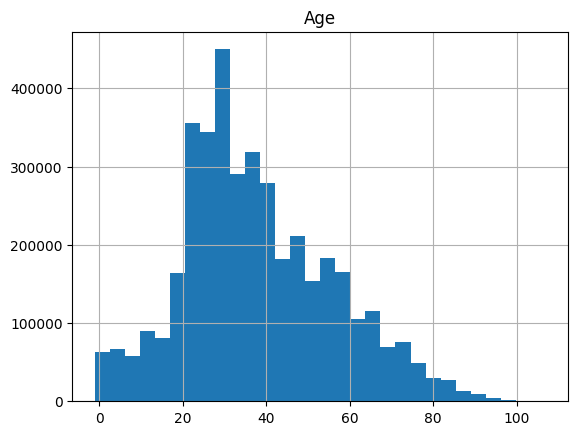

In [34]:
df.hist('Age', bins=30)

This is the mean of the `Age` column.

In [35]:
df['Age'].mean(numeric_only=True)

np.float64(37.81451171975221)

This is the median of the `Age` column.

In [36]:
df['Age'].median(numeric_only=True)

np.float64(35.0)

There are 2 invalid values for `Age` they may be accidental wrong inputs, so we treat them the same as `NaNs`.

In [37]:
nan_count = df[df['Age'].isnull()].shape[0]
invalid_count = df[df['Age'] == -1].shape[0]

print("NaN count: " + str(nan_count))
print("Invalid count: " + str(invalid_count))

NaN count: 9810
Invalid count: 2


In [38]:
df[df['Age'] == -1]

,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,DateRecover,RemovalType,Admitted,RegionRes,ProvRes,CityMunRes,CityMuniPSGC,HealthStatus,Quarantined,DateOnset,Pregnanttab,ValidationStatus
CaseCode,,,,,,,,,,,,,,,,,,,
284007,-1,0 to 4,MALE,2021-03-30,2021-03-30,2021-04-02,NaT,NaT,RECOVERED,NO,NCR,NCR,PASAY CITY,PH137605000,RECOVERED,NO,NaT,NaN,"Removal Type is ""Recovered"", but no Recovered ..."
397879,-1,0 to 4,MALE,2020-05-11,2020-05-12,2020-05-15,NaT,NaT,RECOVERED,NO,NCR,NCR,CITY OF MUNTINLUPA,PH137603000,RECOVERED,YES,NaT,NaN,Age or Birthdate is Invalid\nAge is invalid\nR...


Replace `NaNs` with the median value of the `Age` column.

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

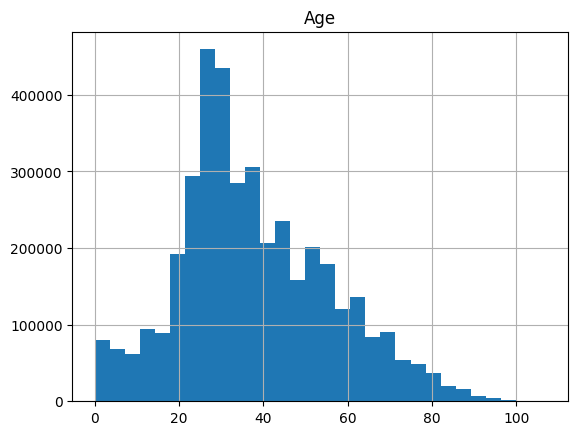

In [39]:
median_age = int(df['Age'].median(numeric_only=True))
df['Age'] = df['Age'].fillna(median_age)
df['Age'] = df['Age'].replace(-1, median_age)
df.hist('Age', bins=30)

#### AgeGroup

We will be handling missing data in the `AgeGroup` column because we have imputed data in the `Age` column. This will be done by re-binning the data for the `AgeGroup` again into the correct ranges.

In [40]:
df['AgeGroup'].unique()

array(['55 to 59', '25 to 29', '30 to 34', '70 to 74', '45 to 49',
       '60 to 64', '20 to 24', '65 to 69', '80+', '50 to 54', '40 to 44',
       '75 to 79', '15 to 19', '35 to 39', '0 to 4', '5 to 9', '10 to 14',
       nan], dtype=object)

<Axes: xlabel='count', ylabel='AgeGroup'>

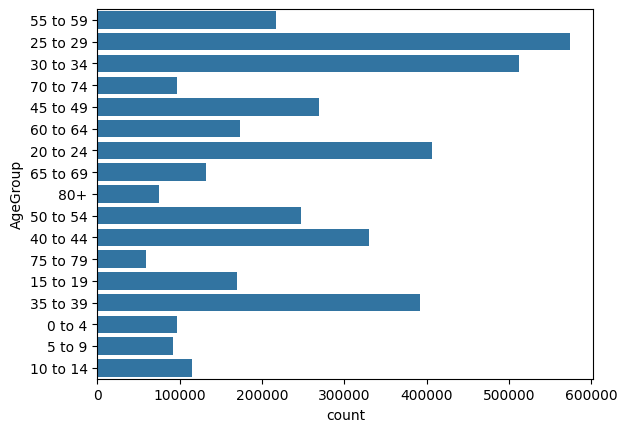

In [41]:
sns.countplot(y=df['AgeGroup'])

Re-bin the values in `Age` to the correct `AgeGroup`.

<Axes: xlabel='count', ylabel='AgeGroup'>

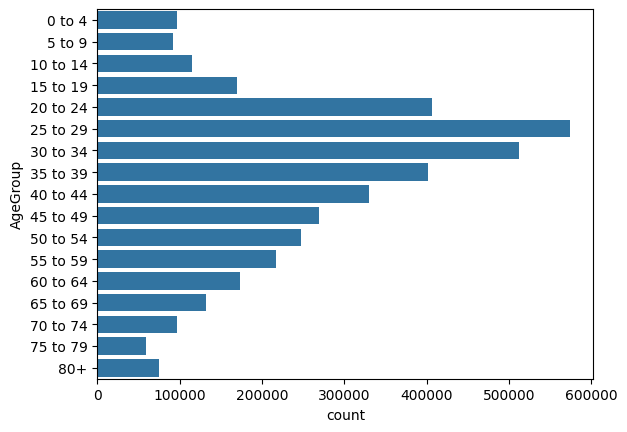

In [42]:
ranges = ['0 to 4', '5 to 9', '10 to 14', '15 to 19', '20 to 24', '25 to 29', '30 to 34', '35 to 39', '40 to 44', '45 to 49', '50 to 54', '55 to 59', '60 to 64', '65 to 69', '70 to 74', '75 to 79', '80+']

bins = list(range(0, 81, 5)) + [np.inf]

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=ranges, right=False)
sns.countplot(y=df['AgeGroup'])

#### Pregnanttab

For the `Pregnanttab` column, rows with `MALE` as their value in the `Sex` column will be automatically imputated with `NA` (Not Applicable), while rows with `FEMALE` as their value in the `Sex` column will be imputated with `NO`, due to it being their median.

##### Male

In [43]:
counts = df[df['Sex'] == 'MALE']['Pregnanttab'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
Pregnanttab,
NaN,1929949


##### Female

In [44]:
counts = df[df['Sex'] == 'FEMALE']['Pregnanttab'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
Pregnanttab,
NaN,80
NO,2035787
YES,93


##### Imputate Pregnanttab

In [45]:
conditions = [
    (df['Sex'] == 'FEMALE') & df['Pregnanttab'].isna(),
    (df['Sex'] == 'MALE') & df['Pregnanttab'].isna()
]
choices = ['NO', 'NA']
df['Pregnanttab'] = np.select(conditions, choices, default=df['Pregnanttab'])

In [46]:
counts = df[df['Sex'] == 'MALE']['Pregnanttab'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
Pregnanttab,
NA,1929949


In [47]:
counts = df[df['Sex'] == 'FEMALE']['Pregnanttab'].value_counts(dropna=False)

nan_row = counts[counts.index.isna()]
other_rows = counts[counts.index.notna()]

result = pd.concat([nan_row, other_rows])
result

,count
Pregnanttab,
NO,2035867
YES,93


### Dropping Columns

This section will be about dropping uneeded columns from the dataframe.

#### DateRecover & DateOnset

`DateOnset` and `DateRecover` will also be dropped due to the fact that there are too many `NaT` values in it, making it hard to interpret with it.

In [48]:
count1 = sum(df['DateRecover'].isnull())
count2 = sum(df['DateOnset'].isnull())

print("NaN count for DateRecover: " + str(count1))
print("NaN count for DateOnset: " + str(count2))

NaN count for DateRecover: 3249608
NaN count for DateOnset: 3249608


#### CityMuniPSGC & ValidationStatus

Columns with `PSGC` will be dropped due to the fact that it is used more for the API of Philippine Statistics Authority.

`ValidationStatus` will also be dropped due to the fact that it is only for logging what went wrong with collecting the obervation.

In [49]:
df = df.drop("CityMuniPSGC", axis=1)
df = df.drop("ValidationStatus", axis=1)
df = df.drop("DateOnset", axis=1)
df = df.drop("DateRecover", axis=1)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3965909 entries, 100000 to 99999956
Data columns (total 15 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Age                Int64         
 1   AgeGroup           category      
 2   Sex                object        
 3   DateSpecimen       datetime64[ns]
 4   DateResultRelease  datetime64[ns]
 5   DateRepConf        datetime64[ns]
 6   DateDied           datetime64[ns]
 7   RemovalType        object        
 8   Admitted           object        
 9   RegionRes          object        
 10  ProvRes            object        
 11  CityMunRes         object        
 12  HealthStatus       object        
 13  Quarantined        object        
 14  Pregnanttab        object        
dtypes: Int64(1), category(1), datetime64[ns](4), object(9)
memory usage: 461.4+ MB


### Dropping Rows

This section will be about dropping rows with too much missing values.

#### DateSpecimen & DateResultRelease

Unfornately, there is not enough context nor information for us to confidently imputate in `DateSpecimen` and `DateResultRelease`. Therefore, we will be dropping rows with both values missing to clean the data further.

In [51]:
df.isnull().sum()

,0
Age,0
AgeGroup,0
Sex,0
DateSpecimen,936789
DateResultRelease,937792
DateRepConf,0
DateDied,3902049
RemovalType,0
Admitted,0
RegionRes,0


In [52]:
ignore_cols = ['DateDied']
check_cols = df.columns.difference(ignore_cols)

df_copy = df.copy(deep=True)
df_copy = df_copy.loc[df_copy[check_cols].isnull().mean(axis=1) < 0.1]
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3063514 entries, 100001 to 99999837
Data columns (total 15 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Age                Int64         
 1   AgeGroup           category      
 2   Sex                object        
 3   DateSpecimen       datetime64[ns]
 4   DateResultRelease  datetime64[ns]
 5   DateRepConf        datetime64[ns]
 6   DateDied           datetime64[ns]
 7   RemovalType        object        
 8   Admitted           object        
 9   RegionRes          object        
 10  ProvRes            object        
 11  CityMunRes         object        
 12  HealthStatus       object        
 13  Quarantined        object        
 14  Pregnanttab        object        
dtypes: Int64(1), category(1), datetime64[ns](4), object(9)
memory usage: 356.4+ MB


In [53]:
df_copy.isnull().sum()

,0
Age,0
AgeGroup,0
Sex,0
DateSpecimen,34394
DateResultRelease,35397
DateRepConf,0
DateDied,3003465
RemovalType,0
Admitted,0
RegionRes,0


In [54]:
cases_df = df_copy

### DOH Dataset Comments

The final row count of the data frame is 3063514, while the final column count is 15. While there may still be missing values in the date columns, it is mostly filled out with data in other columns, which makes it worth keeping it in the data frame.

## Quarantine Timeline CSV

- Source: Official Gazette, IATF Resolutions, and Presidential & Malacañang Public Addresses.

- Link: https://www.officialgazette.gov.ph/ and
https://pco.gov.ph/

- Collection Method: The data for the dataset was manually collected. The timeline was constructed by aggregating data from `Executive Orders` and `IATF resolutions` found in the `Official Gazette` along with `Presidential` and `Malacañang announcements` from the `Presidential Communications Office (PCO)` website.

### Reading the Quarantine Timeline Dataset

The quarantine timline dataset will be read into a dataframe called `timeline_df` below.

In [55]:
timeline_df = pd.read_csv("/content/drive/MyDrive/quarantine_timeline/sorted_quarantine.csv")
timeline_df

,Region/Province/City,Kind of Quarantine,Start Date,End Date,Source
0,Province of Bohol,Community Quarantine,March 16 2020,April 12 2020,Executive Order No. 2020-08 & 14
1,Cebu City,General Community Quarantine,March 16 2020,April 14 2020,Executive Order No. 52
2,City of Iligan,Community Quarantine,March 16 2020,03/20/20,Executive Order No. 29 / Executive Order No. 011
3,Luzon,Enhanced Community Quarantine,March 16 2020,April 12 2020,Proclamation No. 929
4,Lanao Del Sur,Community Quarantine,March 17 2020,April 14 2020,Joint Executive Order No. 001 Series of 2020
...,...,...,...,...,...
138,Cavite,Alert Level 3,Jan 3 2022,Jan 31 2022,IATF Resolutions
139,Kalinga,Alert Level 4,Jan 21 2022,Jan 31 2022,IATF Resolutions
140,Ifugao,Alert Level 4,Jan 21 2022,Jan 31 2022,IATF Resolutions
141,Mt. Province,Alert Level 4,Jan 21 2022,Jan 31 2022,IATF Resolutions


### Renaming and Formatting Region/Province/City

The regions, provinces, and cities aren't standardized into single names for the same place, so there is a need to rename them. The formatting for the places follow the same formatting in `RegionRes`, `ProvRes`, and `CityMunRes` in the case information dataframe.

In [56]:
unique_places = timeline_df['Region/Province/City'].unique()
unique_places

array(['Province of Bohol', 'Cebu City', 'City of Iligan', 'Luzon',
       'Lanao Del Sur', 'Province of Negros Oriental', 'Bacolod City',
       'Province of Leyte', 'Northern Samar', 'Tawi-Tawi', 'Iligan City',
       'Province of Ilo-ilo', 'City of Ilo-ilo', 'South Cotabato',
       'Lanao Del Norte', 'Eastern Samar', 'Province of Antique',
       'Province of Aklan', 'City of Davao', 'City of Lapu-lapu',
       'Province of Cebu', 'Province of Negros Occidental',
       'Davao Region', 'Region XIII (Caraga)', 'Province of Biliran',
       'NCR', 'Central Luzon (except Aurora)', 'Calabarzon', 'Benguet',
       'Pangasinan', 'Iloilo', 'Cebu', 'Bacolod', 'Davao City',
       'Rest of the country (Low-risk areas)', 'Mandaue City',
       'NCR (All HUCs and Pateros)', 'Bataan', 'Bulacan', 'Nueva Ecija',
       'Pampanga', 'Zambales', 'Angeles City', 'Laguna',
       'Rest of the country (not under ECQ/MECQ)', 'Region II',
       'Region III', 'Region IV-A', 'Region VII', 'Zamboanga City

Each of the unique names will be mapped to the correct label.



In [57]:
place_mapping = {
    'Cebu City': 'CITY OF CEBU',
    'Province of Cebu': 'CEBU',
    'Talisay City (Cebu)': 'CITY OF TALISAY',
    'Cebu': 'CEBU',
    'Talisay City': 'CITY OF TALISAY',
    'Province of Bohol': 'BOHOL',
    'Bohol': 'BOHOL',
    'Province of Negros Oriental': 'NEGROS ORIENTAL',
    'Negros Oriental': 'NEGROS ORIENTAL',
    'Province of Negros Occidental': 'NEGROS OCCIDENTAL',
    'Davao Region': 'Region XI: Davao Region',
    'City of Davao': 'CITY OF DAVAO',
    'Davao City': 'CITY OF DAVAO',
    'NCR (All HUCs and Pateros)': 'NCR',
    'Province of Leyte': 'LEYTE',
    'Province of Ilo-ilo': 'ILOILO',
    'City of Ilo-ilo': 'ILOILO CITY',
    'Iloilo': 'ILOILO',
    'Iloilo City': 'ILOILO CITY',
    'Province of Antique': 'ANTIQUE',
    'Province of Aklan': 'AKLAN',
    'Province of Biliran': 'BILIRAN',
    'Mt. Province': 'MOUNTAIN PROVINCE',
    'City of Iligan': 'ILIGAN CITY',
    'Iligan City': 'ILIGAN CITY',
    'Bacolod City': 'BACOLOD CITY',
    'Bacolod': 'BACOLOD CITY',
    'City of Lapu-lapu': 'LAPU-LAPU CITY',
    'Lapu-Lapu City': 'LAPU-LAPU CITY',
    'Lapu-Lapu': 'LAPU-LAPU CITY',
    'Mandaue City': 'MANDAUE CITY',
    'Mandaue': 'MANDAUE CITY',
    'Angeles City': 'ANGELES CITY',
    'Zamboanga City': 'ZAMBOANGA CITY',
    'Ormoc City': 'ORMOC CITY',
    'Tacloban City': 'TACLOBAN CITY',
    'Isabela (excluding Santiago City)': 'ISABELA (EXCLUDING SANTIAGO CITY)',
    'Santiago City': 'CITY OF SANTIAGO',
    'Puerto Princesa City': 'PUERTO PRINCESA CITY',
    'Region XIII (Caraga)': 'CARAGA',
    'Region II': 'Region II: Cagayan Valley',
    'Region III': 'Region III: Central Luzon',
    'Central Luzon (except Aurora)': 'Region III: Central Luzon (EXCEPT AURORA)',
    'Region IV-A': 'Region IV-A: CALABARZON',
    'Calabarzon': 'Region IV-A: CALABARZON',
    'Region VII': 'Region VII: Central Visayas',
    'Lanao Del Sur': 'LANAO DEL SUR',
    'Lanao del Sur': 'LANAO DEL SUR',
    'Northern Samar': 'NORTHERN SAMAR',
    'N. Samar':  'NORTHERN SAMAR',
    'Eastern Samar': 'EASTERN SAMAR',
    'Tawi-Tawi': 'TAWI-TAWI',
    'South Cotabato': 'SOUTH COTABATO',
    'Abra': 'ABRA',
    'Bataan': 'BATAAN',
    'Batangas': 'BATANGAS',
    'Benguet': 'BENGUET',
    'Bulacan': 'BULACAN',
    'Cagayan': 'CAGAYAN',
    'Cavite': 'CAVITE',
    'Consolacion': 'CONSOLACION',
    'Ifugao': 'IFUGAO',
    'Kalinga': 'KALINGA',
    'Laguna': 'LAGUNA',
    'Lanao Del Norte': 'LANAO DEL NORTE',
    'Leyte': 'LEYTE',
    'Minglanilla': 'MINGLANILLA',
    'Nueva Ecija': 'NUEVA ECIJA',
    'Pampanga': 'PAMPANGA',
    'Pangasinan': 'PANGASINAN',
    'Quirino': 'QUIRINO',
    'Rizal': 'RIZAL',
    'Siquijor': 'SIQUIJOR',
    'Southern Leyte': 'SOUTHERN LEYTE',
    'Zambales': 'ZAMBALES',
    'All other areas not mentioned in GCQ list': 'PHILIPPINES',
    'Rest of the country (Low-risk areas)': 'PHILIPPINES',
    'Rest of the country (not under ECQ/MECQ)': 'PHILIPPINES',
    'Luzon': 'LUZON'
}

timeline_df['Region/Province/City'] = timeline_df['Region/Province/City'].replace(place_mapping)

The dataframe below is used to find the unique names in the 'Region/Province/City' column. The interactive table was used to see all the rows. The function '.unique()' was not used because the names are not separated properly, so it is hard to discern the names from each other.

In [58]:
unique_places = timeline_df[['Region/Province/City']].drop_duplicates()
unique_places.sort_values('Region/Province/City')

,Region/Province/City
119,ABRA
17,AKLAN
48,ANGELES CITY
16,ANTIQUE
6,BACOLOD CITY
...,...
85,SOUTHERN LEYTE
98,TACLOBAN CITY
9,TAWI-TAWI
47,ZAMBALES


### Correcting Date Datatype

The formats for the dates are different, ex: "March 20 2020" or "03/20/2020", it needs to be formatted to be the same format.

In [59]:
timeline_df['Start Date'] = pd.to_datetime(timeline_df['Start Date'], format='mixed')
timeline_df['End Date'] = pd.to_datetime(timeline_df['End Date'], format='mixed')

timeline_df[['Start Date', 'End Date']]

,Start Date,End Date
0,2020-03-16,2020-04-12
1,2020-03-16,2020-04-14
2,2020-03-16,2020-03-20
3,2020-03-16,2020-04-12
4,2020-03-17,2020-04-14
...,...,...
138,2022-01-03,2022-01-31
139,2022-01-21,2022-01-31
140,2022-01-21,2022-01-31
141,2022-01-21,2022-01-31


In [60]:
timeline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Region/Province/City  143 non-null    object        
 1   Kind of Quarantine    143 non-null    object        
 2   Start Date            143 non-null    datetime64[ns]
 3   End Date              143 non-null    datetime64[ns]
 4   Source                143 non-null    object        
dtypes: datetime64[ns](2), object(3)
memory usage: 5.7+ KB


### Renaming and Reformatting the Kinds of Quarantine

'Community Quarantine' is not a term officially accepted by the government, that is why it would be renamed to 'General Community Quarantine', its closest counterpart.

In [61]:
unique_quarantine = timeline_df[['Kind of Quarantine']].drop_duplicates()
unique_quarantine.sort_values('Kind of Quarantine')

,Kind of Quarantine
135,Alert Level 3
139,Alert Level 4
0,Community Quarantine
3,Enhanced Community Quarantine
128,Extreme Enhanced Community Quarantine
1,General Community Quarantine
88,Lockdown
42,Modified Enhanced Community Quarantine
59,Modified General Community Quarantine


In [62]:
timeline_df.loc[timeline_df['Region/Province/City'] == 'BOHOL', 'Kind of Quarantine'] = 'General Community Quarantine'

timeline_df.loc[timeline_df['Region/Province/City'] == 'ILIGAN CITY', 'Kind of Quarantine'] = 'General Community Quarantine'

timeline_df.loc[timeline_df['Region/Province/City'] == 'LANAO DEL SUR', 'Kind of Quarantine'] = 'General Community Quarantine'

timeline_df.loc[timeline_df['Region/Province/City'] == 'CITY OF DAVAO', 'Kind of Quarantine'] = 'General Community Quarantine'

unique_quarantine = timeline_df[['Kind of Quarantine']].drop_duplicates()
unique_quarantine.sort_values('Kind of Quarantine')

,Kind of Quarantine
135,Alert Level 3
139,Alert Level 4
3,Enhanced Community Quarantine
128,Extreme Enhanced Community Quarantine
0,General Community Quarantine
88,Lockdown
42,Modified Enhanced Community Quarantine
59,Modified General Community Quarantine


### Sort the Dataframe by Start Date and Alphabetically

In [63]:
timeline_df = timeline_df.sort_values(by=['Start Date', 'Region/Province/City'], ascending=[True, True])

timeline_df

,Region/Province/City,Kind of Quarantine,Start Date,End Date,Source
0,BOHOL,General Community Quarantine,2020-03-16,2020-04-12,Executive Order No. 2020-08 & 14
1,CITY OF CEBU,General Community Quarantine,2020-03-16,2020-04-14,Executive Order No. 52
2,ILIGAN CITY,General Community Quarantine,2020-03-16,2020-03-20,Executive Order No. 29 / Executive Order No. 011
3,LUZON,Enhanced Community Quarantine,2020-03-16,2020-04-12,Proclamation No. 929
6,BACOLOD CITY,General Community Quarantine,2020-03-17,2020-03-30,Executive Order No. 21 / Executive Order No. 2...
...,...,...,...,...,...
137,RIZAL,Alert Level 3,2022-01-03,2022-01-31,IATF Resolutions
140,IFUGAO,Alert Level 4,2022-01-21,2022-01-31,IATF Resolutions
139,KALINGA,Alert Level 4,2022-01-21,2022-01-31,IATF Resolutions
141,MOUNTAIN PROVINCE,Alert Level 4,2022-01-21,2022-01-31,IATF Resolutions


## Provincial Socioeconomic Rankings CSV

- Source: Cities and Municipalities Competitiveness Index (Department of Trade and Industry)

- Link: https://cmci.dti.gov.ph/

- Collection Method: Web scraping was used to gather data from the website for the socioeconomical rankings of provinces in the Philippines, due to the fact that there were no available csv files that are reputable enough to gather.

### Web Sraping Socioeconomic Rankings for Provinces

The code below automates the retrieval of provincial competitiveness rankings from the Cities and Municipalities Competitiveness Index (CMCI) website for the years 2020, 2021, and 2022.

In [64]:
import requests
import time
from io import StringIO

years = [2020, 2021, 2022]
base_url = "https://cmci.dti.gov.ph/rankings-data.php?unit=Provinces&year="

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
    "Referer": "https://cmci.dti.gov.ph/",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Connection": "keep-alive"
}

ranking_dfs = []

session = requests.Session()
session.headers.update(headers)

session.get("https://cmci.dti.gov.ph/", timeout=10)

for year in years:
    url = base_url + str(year)

    try:
        response = session.get(url, timeout=15)

        if response.status_code == 200:
            html_data = StringIO(response.text)
            tables = pd.read_html(html_data)

            if tables:
                df = tables[0]
                df["Ranking_Year"] = year
                ranking_dfs.append(df)
                print(f"Successfully scraped {year}")
            else:
                print(f"No tables found for {year}")
        else:
            print(f"Failed {year} — Status Code: {response.status_code}")

    except requests.exceptions.RequestException as e:
        print(f"Request error for {year}: {e}")

    time.sleep(2)

if ranking_dfs:
    ranking_df = pd.concat(ranking_dfs, ignore_index=True)

    output_file = "cmci_provincial_rankings_2020_2022.csv"
    ranking_df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"\nData saved to {output_file}")
    print(ranking_df.head())
else:
    print("No data was collected.")

Failed 2020 — Status Code: 403
Failed 2021 — Status Code: 403
Failed 2022 — Status Code: 403
No data was collected.


#### Explanation If There is an Error 403

Since NCR is not a province, the cities of NCR will also be manually scrapped and its total scores will be averaged.

`Note:` This snippet must be ran by a local computer due to the fact that the website is highly aggressive in blocking scripts like web scrappers. The snippet uses FireFox as its webdriver to mimic a user accessing the website, but you may change the webdriver to your preferred website.

```
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.firefox import GeckoDriverManager
import pandas as pd
from io import StringIO

firefox_options = Options()
firefox_options.add_argument("--headless")

years = [2020, 2021, 2022]
results = []

driver = webdriver.Firefox(
    service=Service(GeckoDriverManager().install()),
    options=firefox_options
)

try:
    for year in years:
        print(f"Connecting to {year}...")
        url = f"https://cmci.dti.gov.ph/rankings-data.php?unit=Highly%20Urbanized%20Cities&year={year}"
        driver.get(url)

        try:
            WebDriverWait(driver, 20).until(
                EC.presence_of_element_located((By.XPATH, "//table[@id='table_data1']/tbody/tr"))
            )

            table = driver.find_element(By.ID, "table_data1")
            table_html = table.get_attribute("outerHTML")

            df = pd.read_html(StringIO(table_html))[0]

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = [' '.join([str(i) for i in col if i]).strip() for col in df.columns]

            region_col = next(c for c in df.columns if "Region" in c)
            score_col = next(c for c in df.columns if c.startswith("Score"))

            df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

            ncr_df = df[df[region_col].astype(str).str.contains("NCR", case=False, na=False)]

            avg_score = ncr_df[score_col].mean()

            results.append({
                "Province": "NATIONAL CAPITAL REGION (NCR)",
                "Ranking_Year": year,
                "Score": avg_score
            })

            print(f"{year}: Avg NCR Score = {avg_score:.4f}")

        except Exception as e:
            print(f"{year} failed: {e}")

finally:
    driver.quit()

if results:
    final_df = pd.DataFrame(results)
    final_df.to_csv("output.csv", index=False)
    print("\nSaved to output.csv")
else:
    print("Failed to capture any data.")
```

### Reading the Provincial Ranking CSV

A csv file that contains this content has already been prepared in case of the webscraper not working due to the security of the website.

In [65]:
rankings_df = pd.read_csv('/content/drive/MyDrive/socioeconomics and population/cmci_provincial_rankings_2020_2022.csv')
rankings_df

,Rank,Score,Province,Region,Ranking_Year
0,1st,51.5250,Rizal,REGION IV-A (CALABARZON),2020
1,2nd,50.3919,Davao Del Norte,REGION XI (Davao Region),2020
2,3rd,47.8568,Camiguin,REGION X (Northern Mindanao),2020
3,4th,47.4095,Laguna,REGION IV-A (CALABARZON),2020
4,5th,46.5593,Cavite,REGION IV-A (CALABARZON),2020
...,...,...,...,...,...
234,78th,24.1173,Tawi-Tawi,BARMM - Bangsamoro Autonomous Region in Muslim...,2022
235,79th,22.9991,Masbate,REGION V (Bicol Region),2022
236,80th,22.8291,Batanes,REGION II (Cagayan Valley),2022
237,81st,17.2784,Basilan,BARMM - Bangsamoro Autonomous Region in Muslim...,2022


### Group and Sort Provinces

Group the provinces according to name and compile their score throughout the years.

In [66]:
rankings_df = rankings_df.groupby(['Province', 'Ranking_Year'])['Score'].first().unstack()
rankings_df.columns.name = None
rankings_df = rankings_df.reset_index()
rankings_df['Province'] = rankings_df['Province'].str.upper()
rankings_df

,Province,2020,2021,2022
0,ABRA,34.9105,32.5359,25.4537
1,AGUSAN DEL NORTE,36.2011,33.3630,29.1799
2,AGUSAN DEL SUR,37.9942,33.4347,29.3079
3,AKLAN,39.6627,33.7119,30.7996
4,ALBAY,42.1993,34.4860,32.6410
...,...,...,...,...
79,TAWI-TAWI,NaN,25.7325,24.1173
80,ZAMBALES,38.0738,32.0445,29.0407
81,ZAMBOANGA DEL NORTE,37.0211,33.7801,28.8895
82,ZAMBOANGA DEL SUR,38.1755,33.6485,29.2569


## Provincial Population CSV

- Source: Philippine Statistics Authority

- Link: https://psa.gov.ph/content/2020-census-population-and-housing-2020-cph-population-counts-declared-official-president

- Collection Method: The data for the dataset was manually encoded. Only the province's name and its population in 2020 from the "Population and Annual Growth Rate for the Philippines and its Regions, Provinces, and Highly Urbanized Cities" was encoded. Futhermore, the populations for 2021 and 2022 were manually computed using the growth rate provided by the PSA.

### Reading the Population Data CSV

For the population of provinces, the data was gathered from the `2020 Census of Population and Housing (2020 CPH) Population Counts Declared Official by the President`.

In [67]:
population_df = pd.read_csv('/content/drive/MyDrive/socioeconomics and population/philippine_provinces_population.csv')
population_df

,Province,2020 Recorded Population,2021 Projected Population,2022 Projected Population
0,NATIONAL CAPITAL REGION (NCR),13484462,13607171,13710585
1,APAYAO,124366,125498,126452
2,BENGUET,827041,834567,840910
3,IFUGAO,207498,209386,210978
4,KALINGA,229570,231659,233420
...,...,...,...,...
76,AGUSAN DEL NORTE,760413,767333,773164
77,AGUSAN DEL SUR,739367,746095,751766
78,DINAGAT ISLANDS,128117,129283,130265
79,SURIGAO DEL NORTE,534636,539501,543601


### Aggregating With Other Datasets

This code reshapes and merges multiple datasets to analyze COVID-19 cases relative to population and income rankings by province.

- First, it converts both the population and rankings data from wide to long format, extracting the year, and aligning the provinces.

- Next, it aggregates the population by province and year, and averages the ranking scores for the same groups. Then, it merges the case counts with the population and ranking data, creating a unified dataset for analysis.

- Finally, it calculates COVID-19 incidence per 100,000 people and classifies provinces into four income groups based on ranking scores. This allows comparison of case rates across different income levels and provinces over time.

In [68]:
import pandas as pd
import numpy as np

pop_long = population_df.melt(
    id_vars=['Province'],
    value_vars=[c for c in population_df.columns if 'Population' in c],
    var_name='Year', value_name='Population'
)
pop_long['Year'] = pop_long['Year'].str.extract(r'(\d+)').astype(int)

rank_id_col = rankings_df.columns[0]
rank_val_cols = rankings_df.columns[1:]
rank_long = rankings_df.melt(
    id_vars=[rank_id_col],
    value_vars=rank_val_cols,
    var_name='Year', value_name='Score'
)
rank_long['Year'] = rank_long['Year'].astype(str).str.extract(r'(\d+)').astype(int)
rank_long.rename(columns={rank_id_col: 'Province'}, inplace=True)

cases_df['Year'] = cases_df['DateSpecimen'].dt.year
case_counts = cases_df.groupby(['ProvRes', 'Year']).size().reset_index(name='Cases')

pop_long = pop_long.groupby(['Province', 'Year'])['Population'].sum().reset_index()
rank_long = rank_long.groupby(['Province', 'Year'])['Score'].mean().reset_index()

analysis_df = pd.merge(case_counts, pop_long, left_on=['ProvRes', 'Year'], right_on=['Province', 'Year'], how='inner')
analysis_df = pd.merge(analysis_df, rank_long, on=['Province', 'Year'], how='inner')

analysis_df['Cases_per_100k'] = (analysis_df['Cases'] / analysis_df['Population']) * 100000
analysis_df['Income_Group'] = pd.qcut(analysis_df['Score'], 4, labels=['Low Income', 'Lower Mid', 'Upper Mid', 'High Income'])

analysis_df

,ProvRes,Year,Cases,Province,Population,Score,Cases_per_100k,Income_Group
0,AGUSAN DEL NORTE,2020.0,1642,AGUSAN DEL NORTE,760413,36.2011,215.935288,Upper Mid
1,AGUSAN DEL NORTE,2021.0,13406,AGUSAN DEL NORTE,767333,33.3630,1747.090246,Upper Mid
2,AGUSAN DEL NORTE,2022.0,4306,AGUSAN DEL NORTE,773164,29.1799,556.932294,Low Income
3,AGUSAN DEL SUR,2020.0,799,AGUSAN DEL SUR,739367,37.9942,108.065413,High Income
4,AGUSAN DEL SUR,2021.0,9203,AGUSAN DEL SUR,746095,33.4347,1233.489033,Upper Mid
...,...,...,...,...,...,...,...,...
235,ZAMBOANGA DEL SUR,2021.0,27114,ZAMBOANGA DEL SUR,2046356,33.6485,1324.989396,Upper Mid
236,ZAMBOANGA DEL SUR,2022.0,11085,ZAMBOANGA DEL SUR,2061908,29.2569,537.608855,Low Income
237,ZAMBOANGA SIBUGAY,2020.0,179,ZAMBOANGA SIBUGAY,669840,31.9438,26.722799,Lower Mid
238,ZAMBOANGA SIBUGAY,2021.0,3855,ZAMBOANGA SIBUGAY,675936,30.4360,570.320267,Low Income


# Dataset Explanation

### DOH Covid Data Drop Dataset


- The dataset comprises all the cases recorded for the COVID-19 pandemic in the Philippines, from the beginning of `2020` to the end of `2022`.

- `CaseCode` is the unique code used to store each case.

- `Age` is the age of the person.

- `AgeGroup` is the category the patient belongs to in terms of their age.

- `Sex`indicates the sex of the patient.

- `DateSpecimen` is the date when their COVID-19 test was taken.

- `DateResultRelease` is the date when the result of the aforementioned test was released.

- `DateRepConf` is the date when the user was recorded as "confirmed" to have COVID-19 in the database of the Department of Health.

- `DateDied` and `DateRecover` recorded the date of death or the date of recovery.

- `RemovalType` indicated how the patient was removed from the DOH's list of active cases, either through death or recovery.

- `Admitted` indicates whether the patient was admitted to a hospital when they were infected with COVID-19.

- `RegionRes`, `ProvRes`, `CityMunRes`, and `BarangayRes` all refer to the patient's official place of residence at different administrative levels (Region, Province, City, and lastly, Barangay).

- `CityMuniPSGC` and `BarangayPSGC` refer to the city and barangay's PSGC code. PSGC, which stands for Philippine Standard Geographic Code, is the government's way of processing data that requires geographical disaggregation (breaking down into specifics to check trends in smaller areas).

- `Quarantined` indicates whether the patient has been quarantined at some point following a COVID-19 infection.

- `DateOnset` indicates the date when symptoms first started showing.

- `Pregnant` indicates whether the patient is pregnant.

- `ValidationStatus` indicates the completeness and consistency of the data in the record (e.g., lacking age/birthdate, lacking recovery date, etc.).

`Implications:`

- There have been public concerns regarding inconsistencies and reporting delays in the DOH COVID-19 Data Drop. While auditing the primary data collection is outside the scope of this project, these potential limitations should be considered when interpreting our results.

- Furthermore, the dataset contained a significant number of missing values (NaNs). While we did rigorous cleaning and imputations to mitigate this, inherent inaccuracies from the raw data may remain and could influence the final analysis.

- In our data cleaning, which filtered out rows that are `NaN` in both `DateSpecimen` and `DateResultRelease`resulted in the removal of approximately 900,000 confirmed cases. That means the resulting data may underestimate the true magnitude of daily cases, creating a 'survivorship bias' where only cases with complete data are visualized.

### Quarantine Timeline CSV

- `Region/Province/City` is the specific region, province, or city where a quarantine occured.

- `Kind of Quarantine` is the specific quaratine being implemented which are (ECQ, MECQ, GCQ, MGCQ, and Alert Levels 1-5).

- `Start Date` is the starting date of the quarantine implementation.

- `End Date` is the ending date of the quarantine implementation.

- `Source` is where the data from that row is sorced from.

`Implications:`
- The Quarantine Timeline was constructed through the manual gathering and encoding data from government sources (Official Gazette, IATF, and LGU announcements). Consequently, the dataset carries an inherent risk of human transcription error.

- Furthermore, many quarantine protocols were disseminated via verbal press briefings often lacking immediate written documentation. This reliance on verbal sources introduces ambiguity and potential gaps in the timeline, particularly for localized lockdowns where archived records are scarce.

### Province Ranking

- `Rank` is the numerical rank of the province compared to others.

- `Score` is the calculated score of the province.

- `Province` is the name of the province.

- `Region` is the region where the province is located.

- `Ranking-Year` is the year the provinces were ranked.

`Implications:`
- A province's ranking is determined by the overall scores of its cities and municipalities, weighted according to their population and income. Since there was no available ranking for NCR, the mean score of the cities in NCR was used in computing its score. Thus, this may affect NCR's true standing among the provinces. However, since NCR is the Philippines' most developed region, it is still expected to score well above most other provinces.

### Province Population

- `Province` is the name of the province.

- `2020 Recorded Population` is the official recorded population for that province by the PSA.

- `2021 Projected Population` is the computed population for that province using the growth rate.

- `2022 Projected Population` is the computed population for that province using the growth rate.

`Implications:`

- The original data contained population data for 2000, 2010, 2015, and 2020, along with growth rates for multiple intervals (2000-2020). For this dataset, we omitted the population data for the previous years except for 2020, and added the populations of independent cities back into their parent provinces. This ensures our data covers the entire geographic area, rather than treating cities and provinces separately.

- Populations for 2021 and 2022 were projected using specific annual growth rates. While this extrapolation is necessary because the PSA does not record annual provincial data, it may inaccurately represent the exact population counts for those years compared to a census.

# Exploratory Data Analysis

## Summary Statistics

- Beginning with our first EDA Question: What are the common demographic, geographic, admission characteristics of COVID-19 patients based on the measure of central tendencies?

- We will be focusing on the measure of central tendency of the following variables: Age, Sex, Admitted, Region, Province, and Quarantined.

In [69]:
cases_df

,Age,AgeGroup,Sex,DateSpecimen,DateResultRelease,DateRepConf,DateDied,RemovalType,Admitted,RegionRes,ProvRes,CityMunRes,HealthStatus,Quarantined,Pregnanttab,Year
CaseCode,,,,,,,,,,,,,,,,
100001,26,25 to 29,MALE,2022-01-02,2022-01-03,2022-01-31,NaT,RECOVERED,NO,Region IV-A: CALABARZON,CAVITE,IMUS CITY,RECOVERED,NO,NA,2022.0
100003,71,70 to 74,MALE,2021-03-31,2021-03-31,2021-04-03,NaT,RECOVERED,NO,NCR,NCR,QUEZON CITY,RECOVERED,NO,NA,2021.0
100004,45,45 to 49,MALE,2021-03-19,2021-03-21,2021-03-23,NaT,RECOVERED,NO,NCR,NCR,CITY OF MALABON,RECOVERED,NO,NA,2021.0
100006,62,60 to 64,MALE,2021-03-28,2021-03-29,2021-03-31,2021-04-20,DIED,NO,Region III: Central Luzon,NUEVA ECIJA,QUEZON,DIED,NO,NA,2021.0
100007,26,25 to 29,FEMALE,2020-09-20,2020-09-22,2020-09-24,NaT,RECOVERED,NO,NCR,NCR,QUEZON CITY,RECOVERED,NO,NO,2020.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99999700,59,55 to 59,MALE,2022-01-17,2022-01-17,2022-01-21,NaT,RECOVERED,NO,Region IV-A: CALABARZON,LAGUNA,CITY OF SANTA ROSA,RECOVERED,NO,NA,2022.0
99999759,24,20 to 24,FEMALE,2022-07-12,2022-07-12,2022-07-15,NaT,RECOVERED,NO,Region III: Central Luzon,BULACAN,PANDI,RECOVERED,NO,NO,2022.0
99999781,4,0 to 4,FEMALE,2022-01-06,2022-01-07,2022-01-10,NaT,RECOVERED,NO,Region IV-A: CALABARZON,RIZAL,CITY OF ANTIPOLO (CAPITAL),RECOVERED,NO,NO,2022.0


#### Age Distribution

Calculating for Age's central tendencies.

In [70]:
age_summary = cases_df['Age'].describe()
age_summary['mode'] = cases_df['Age'].mode()[0]
age_summary['variance'] = cases_df['Age'].var()

age_summary

,Age
count,3063514.0
mean,37.599777
std,18.635278
min,0.0
25%,25.0
50%,35.0
75%,50.0
max,107.0
mode,26.0
variance,347.273582


The cleaned dataset includes 3,063,514 individuals with recorded ages. The average age of the people who were infected by COVID-19 is 37.6 years, with a standard deviation of 18.6, median being 35 years and a mode of 26 years.

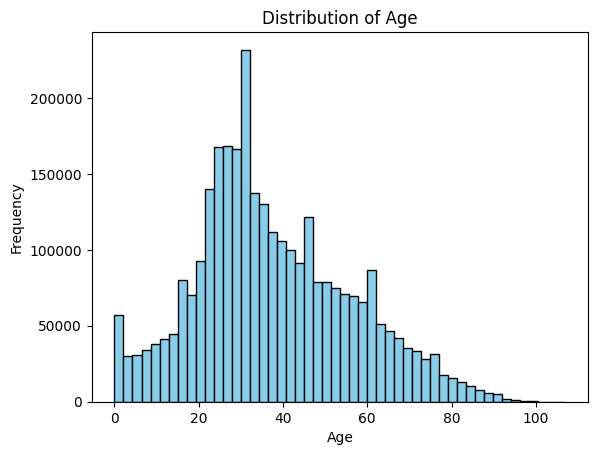

In [71]:
plt.hist(cases_df['Age'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The histogram shows that the age distribution has a slightly right skew because of the mean being slightly higher than the median. The graph also shows the wide age range of all individuals involved, from ages 0 to 107 years. The interquartile range is from 25-50 years, and as seen in the graph, most of the population peaks at that certain range, indicating that half of the individuals are between young adulthood to middle aged group.

#### Sex Distribution

Calculating for Sex's count and distribution.

In [72]:
cases_df['Sex'].describe()

,Sex
count,3063514
unique,2
top,FEMALE
freq,1598132


Out of the 3,063,514 individuals, 1,598,132 among them are FEMALE, which is about 52.17% of the population.

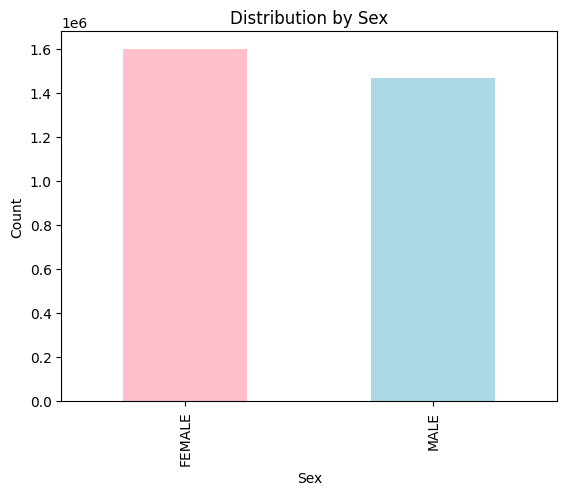

In [73]:
cases_df['Sex'].value_counts().plot(kind='bar', color=['pink','lightblue'])
plt.title('Distribution by Sex')
plt.ylabel('Count')
plt.show()

#### Admitted Distribution

Calculating for Admitted's count and distribution.

In [74]:
cases_df['Admitted'].describe()

,Admitted
count,3063514
unique,2
top,NO
freq,2975734


Majority, 97.13% of the population, are not admitted to the hospital after contracting COVID-19

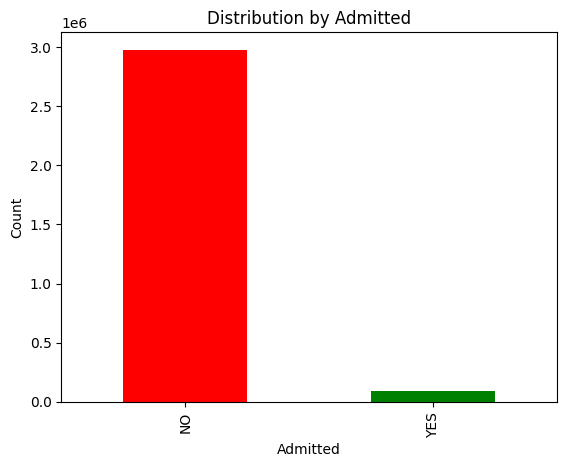

In [75]:
cases_df['Admitted'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Distribution by Admitted')
plt.ylabel('Count')
plt.show()

In [76]:
cases_df['RegionRes'].describe()

,RegionRes
count,3063514
unique,19
top,NCR
freq,930288


#### Population and Case Count

Since the metro area is busy and extremely populated compared to other regions, most of the people who were confirmed to have had COVID-19 were from the NCR region.

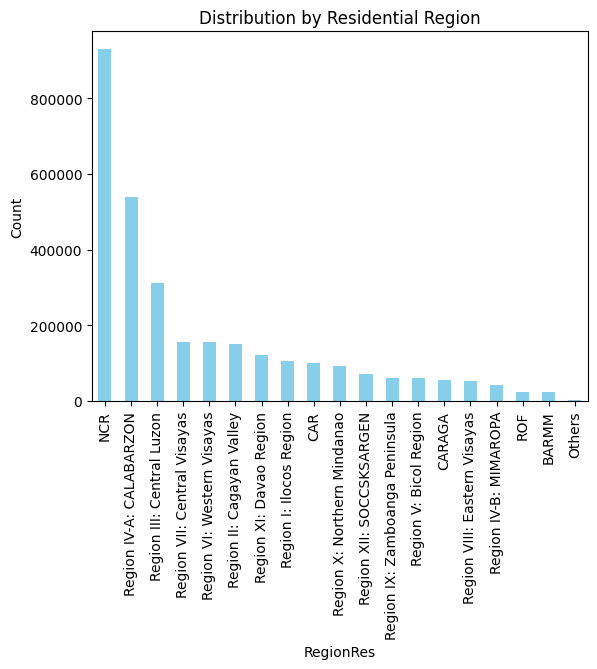

In [77]:
cases_df['RegionRes'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution by Residential Region')
plt.ylabel('Count')
plt.show()

NCR is then followed by CALABARZON, Central Luzon, Central Visayas, and so on.

In [78]:
cases_df['ProvRes'].describe()

,ProvRes
count,3063514
unique,85
top,NCR
freq,925017


Similar to residential region, NCR still remains as the province to have the most confirmed COVID-19 cases out of 85 provinces.

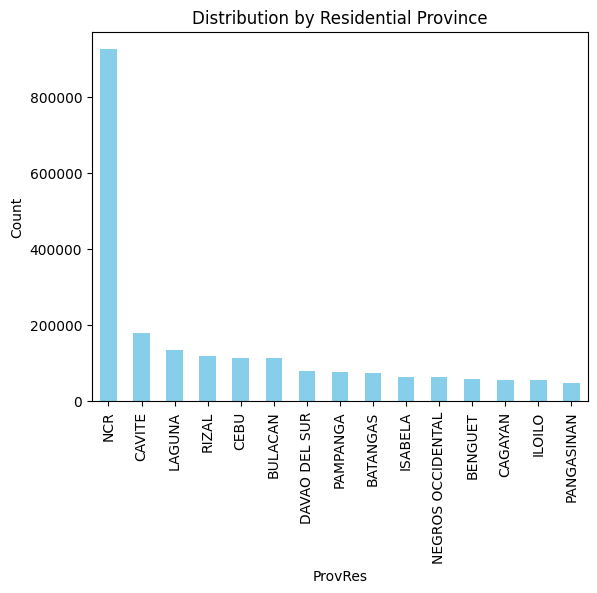

In [79]:
cases_df['ProvRes'].value_counts().head(15).plot(kind='bar', color='skyblue')
plt.title('Distribution by Residential Province')
plt.ylabel('Count')
plt.show()

Since there is not enough room to fit all 85 provincial residences, we have taken the top 15 provinces with the most confirmed number of COVID-19 cases. NCR takes the lead, followed by CAVITE, LAGUNA, RIZAL, CEBU, and so on.

#### Quarantine Distribution

Calculating Quarantined's count and distribution.

In [80]:
cases_df['Quarantined'].describe()

,Quarantined
count,3063514
unique,2
top,NO
freq,2607153


Most of the population has said that they have NOT been quarantined at some point after contracting a COVID-19 infection.

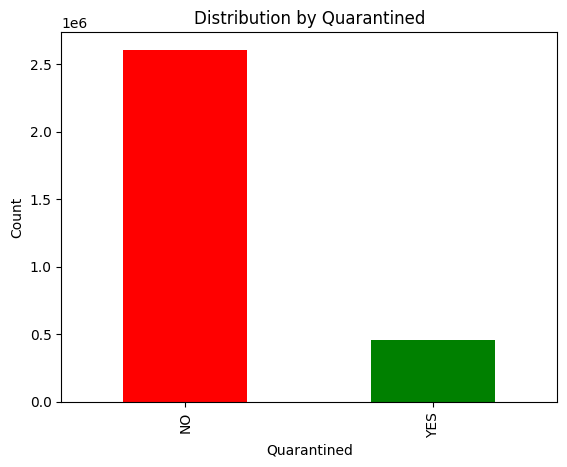

In [81]:
cases_df['Quarantined'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Distribution by Quarantined')
plt.ylabel('Count')
plt.show()


#### First and Last Cases in the Dataset

In [82]:
cases_df['DateRepConf'].min()

Timestamp('2020-01-30 00:00:00')

In [83]:
cases_df['DateRepConf'].max()

Timestamp('2022-11-26 00:00:00')

In our dataset, the first case of a confirmed COVID-19 case was recorded on January 30, 2020, while the latest was recorded on November 26, 2022.

##Data Visualization

#### Income and Case Count

- For the second EDA Question: Is there a significant difference in the volume of cases of the rate of infection between high-income provinces and low-income provinces?

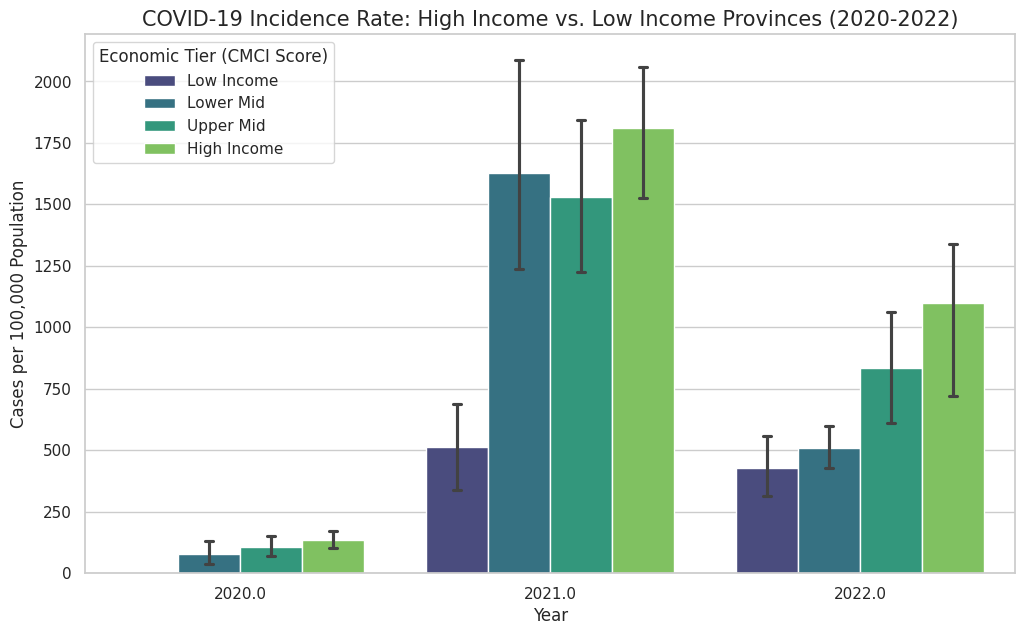

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=analysis_df,
    x='Year',
    y='Cases_per_100k',
    hue='Income_Group',
    palette='viridis',
    capsize=.1
)

plt.title('COVID-19 Incidence Rate: High Income vs. Low Income Provinces (2020-2022)', fontsize=15)
plt.ylabel('Cases per 100,000 Population', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Economic Tier (CMCI Score)', loc='upper left')

plt.show()

Since the population of each province differs significantly, we need to compare them not just by the total number of cases, but by the number of cases per 100,000 people. This helps provide a standardized measure of incidence, allowing for a fair comparison between provinces of varying population sizes.

- Richer provinces, such as NCR, have the highest COVID-19 incidence rates, likely due to their larger populations and higher levels of human mobility. Overall, income appears to strongly affect COVID-19 incidence, as while mid- and high-income provinces exhibit similar rates, lower income provinces have lower incidence rates, which may be associated with lower population density, fewer employment opportunities, and reduced human mobility.

- Futhermore, it is important to note that the lower case counts in certain regions may be attributed to socio-economic factors rather than lower transmission rates. Limited hospital infrastructure and reduced access to diagnostic testing in impoverished areas likely led to a significant underreporting of cases.

#### Quarantine Interval and Case Count

- For our third EDA question, How did the number of confirmed cases change over time in the areas with most quarantine periods in relation to the implementation of different quarantine levels?

We want to see the relationship between the quarantine classification periods and the number of cases that have manifested during that quarantine period per Province or City.

Since our DataFrame consists of multiple provinces and cities, we will select the top 6 with the most quarantine intervals.

In [85]:
area_cq = timeline_df['Region/Province/City'].value_counts().reset_index()
area_cq.columns = ['Location', 'Quarantine Counts']
area_cq = area_cq.sort_values(by='Quarantine Counts', ascending=False)
area_top_cq = area_cq.head(6)
area_top_cq

,Location,Quarantine Counts
0,NCR,17
1,CITY OF CEBU,6
2,BULACAN,6
3,LAGUNA,5
4,RIZAL,5
5,CAVITE,5


Given timeline_df's variable, Kind of Quarantine, the data consists of the types of quarantine periods; however, they will be mapped according	to their abbreviated name.

In [86]:
quarantine_mapping = {
    'Enhanced Community Quarantine': 'ECQ',
    'Modified Enhanced Community Quarantine': 'MECQ',
    'General Community Quarantine': 'GCQ',
    'Modified General Community Quarantine': 'MGCQ',
    'Alert Level 3': 'AL3',
    'Alert Level 4': 'AL4'
}

timeline_df['QuarantineCode'] = timeline_df['Kind of Quarantine'].map(quarantine_mapping)

We will now apply colors to each quaratine classification for identifying the type of quarantine.

In [87]:
colors = {
    'ECQ': 'red',
    'MECQ': 'orange',
    'GCQ': 'yellow',
    'MGCQ': 'green',
    'AL3': 'blue',
    'AL4': 'purple'
}

We now map the locations that do not match such as 'CITY OF CEBU' from `timeline_df` to 'CEBU CITY (CAPITAL)' in `cases_df`.

In [88]:
area_top_cq = area_top_cq.copy()
area_top_cq['Location'] = area_top_cq['Location'].replace({
    'CITY OF CEBU': 'CEBU CITY (CAPITAL)'
})

To collect the number of confirmed number of cases per day, we recorded the location, date confirmed, and the aggregated count. All of the data collected should be in the 'Location' variable of `area_top_cq` to ensure that we have chosen the locations with the highest counts of quarantine intervals.

In [89]:
target_cities = ['CEBU CITY (CAPITAL)']

cases_cities = cases_df[cases_df['CityMunRes'].isin(target_cities)]

province_daily = cases_df.groupby(['ProvRes', 'DateRepConf']).size().reset_index(name='Cases')
city_daily = cases_cities.groupby(['CityMunRes', 'DateRepConf']).size().reset_index(name='Cases')

province_daily_filtered = province_daily[province_daily['ProvRes'].isin(area_top_cq['Location'])]
city_daily_filtered = city_daily[city_daily['CityMunRes'].isin(area_top_cq['Location'])]

To combine both provinces and cities from cases_df, both 'ProvRes' and 'CityMunRes' is renamed to 'Location' for concatenation.


In [90]:
#rename to location for concatenating
province_daily_filtered = province_daily_filtered.rename(columns={'ProvRes': 'Location'})
city_daily_filtered = city_daily_filtered.rename(columns={'CityMunRes': 'Location'})

combined_daily = pd.concat([province_daily_filtered, city_daily_filtered], ignore_index=True)

Display the filtered locations, date confirmed and the number of aggregated cases.

In [91]:
combined_daily

,Location,DateRepConf,Cases
0,BULACAN,2020-03-21,1
1,BULACAN,2020-03-23,3
2,BULACAN,2020-03-27,1
3,BULACAN,2020-03-28,5
4,BULACAN,2020-03-29,2
...,...,...,...
5781,CEBU CITY (CAPITAL),2022-11-22,12
5782,CEBU CITY (CAPITAL),2022-11-23,15
5783,CEBU CITY (CAPITAL),2022-11-24,25
5784,CEBU CITY (CAPITAL),2022-11-25,27


##### Graphs

To visualize the daily COVID-19 cases per Province/City, we utilized the `Matplotlib` library to use a line graph with the Y-axis as the number of daily cases and the X-axis as dates from 2020 to 2022. We also included color patches, or intervals, of the different types of Quarantine Classifications that were implemented by the government at that certain time period.

###### NCR

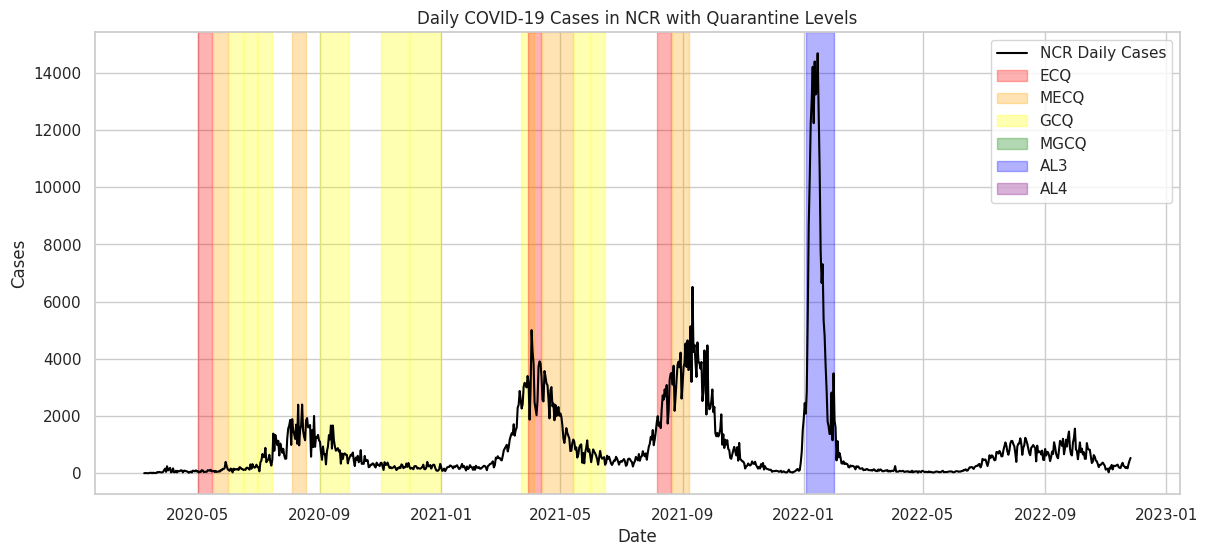

In [92]:
from matplotlib.lines import Line2D
import matplotlib.patches as mplp
area_to_plot = 'NCR'

data = combined_daily[combined_daily['Location'] == area_to_plot]

plt.figure(figsize=(14,6))
plt.plot(data['DateRepConf'], data['Cases'], color='black', label=f'{area_to_plot} Daily Cases')

for i, row in timeline_df.iterrows():
    if row['Region/Province/City'] == area_to_plot:
        plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.3)

legend_patches = [mplp.Patch(color=color, alpha=0.3, label=label) for label, color in colors.items()]
daily_cases = Line2D([0], [0], color='black', linestyle='-', label=f'{area_to_plot} Daily Cases')

plt.title(f'Daily COVID-19 Cases in {area_to_plot} with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(handles=[daily_cases] + legend_patches)
plt.show()

Cases stayed low from March to May 2020 during the first ECQ, but numbers slowly began to rise towards the end of the implementation of GCQ then hiked into an MECQ during August 2020 as it reached a significant peak. The implementation of ECQs during 2021 coincide with the near peak of the cases, which only begin to die down during the subsequent MECQs and GCQs. During the major spike of the beginning of 2022, they immediately implemented Alert Level 3, this new peak most likely was the effect of family gatherings during Christmas and the New Year.

###### Cebu City

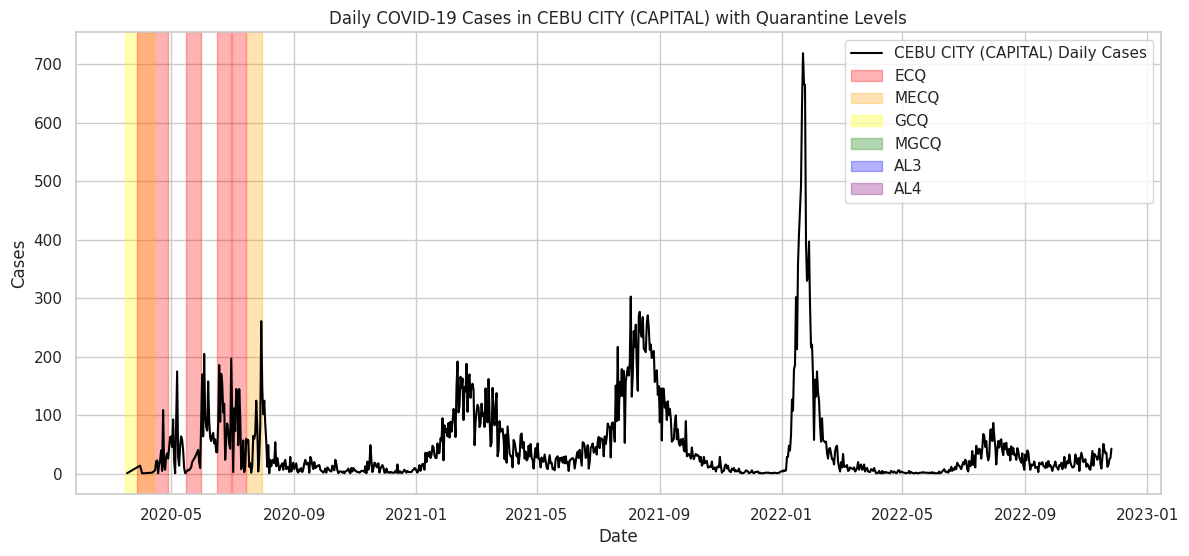

In [93]:
area_to_plot = 'CEBU CITY (CAPITAL)'

data = combined_daily[combined_daily['Location'] == area_to_plot]

plt.figure(figsize=(14,6))
plt.plot(data['DateRepConf'], data['Cases'], color='black', label=f'{area_to_plot} Daily Cases')

for i, row in timeline_df.iterrows():
    if row['Region/Province/City'] == 'CITY OF CEBU':
        plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.3)

legend_patches = [mplp.Patch(color=color, alpha=0.3, label=label) for label, color in colors.items()]
daily_cases = Line2D([0], [0], color='black', linestyle='-', label=f'{area_to_plot} Daily Cases')

plt.title(f'Daily COVID-19 Cases in {area_to_plot} with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(handles=[daily_cases] + legend_patches)
plt.show()

Cebu had multiple instances of ECQs during 2020, and noticeably has a bigger spike ratio compared to NCR's 2020 cases, especially during the MECQ period. Cebu stayed in ECQ while the rest of the country was in GCQ. The cases reach their highest point when the lockdown was reimposed. Alert Level 3 was implemented after the new year of 2022.

###### Bulacan

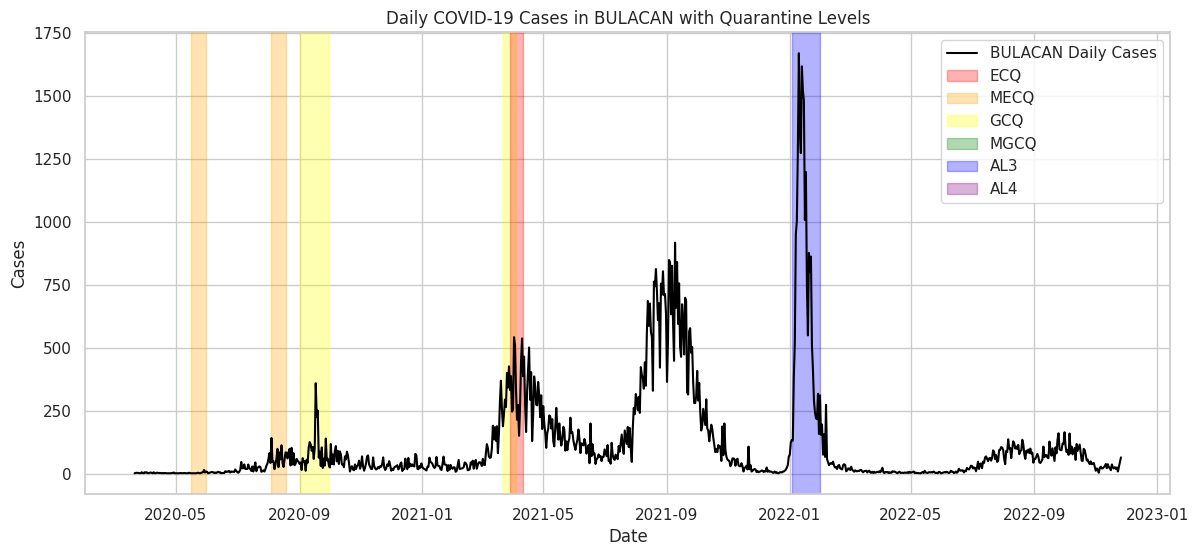

In [94]:
area_to_plot = 'BULACAN'

data = combined_daily[combined_daily['Location'] == area_to_plot]

plt.figure(figsize=(14,6))
plt.plot(data['DateRepConf'], data['Cases'], color='black', label=f'{area_to_plot} Daily Cases')

for i, row in timeline_df.iterrows():
    if row['Region/Province/City'] == area_to_plot:
        plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.3)

legend_patches = [mplp.Patch(color=color, alpha=0.3, label=label) for label, color in colors.items()]
daily_cases = Line2D([0], [0], color='black', linestyle='-', label=f'{area_to_plot} Daily Cases')

plt.title(f'Daily COVID-19 Cases in {area_to_plot} with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(handles=[daily_cases] + legend_patches)
plt.show()

Cases stayed low during the first half of 2020 with a MECQ period during May-June, nearing September however, cases began to rise during the brief MECQ period. In 2021, the first ECQ was implemented because of the first big peak in cases, after the ECQ implementation, cases slowly began to die down.

###### Laguna

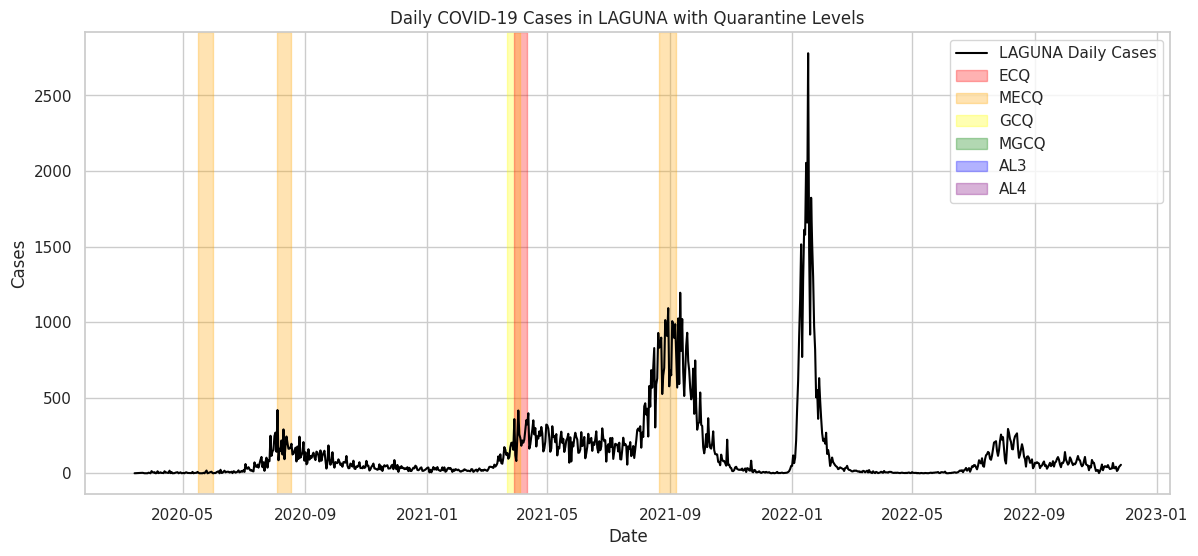

In [95]:
area_to_plot = 'LAGUNA'

data = combined_daily[combined_daily['Location'] == area_to_plot]

plt.figure(figsize=(14,6))
plt.plot(data['DateRepConf'], data['Cases'], color='black', label=f'{area_to_plot} Daily Cases')

for i, row in timeline_df.iterrows():
    if row['Region/Province/City'] == area_to_plot:
        plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.3)

legend_patches = [mplp.Patch(color=color, alpha=0.3, label=label) for label, color in colors.items()]
daily_cases = Line2D([0], [0], color='black', linestyle='-', label=f'{area_to_plot} Daily Cases')

plt.title(f'Daily COVID-19 Cases in {area_to_plot} with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(handles=[daily_cases] + legend_patches)
plt.show()

Similar to Bulacan, cases remained low during the first half of 2020 and only rose nearing September 2020 where they implemented MECQ after the highest peak so far. Nearing May of 2021, Laguna decided to implement ECQ after the rise of cases, the number of cases was similar to that of August 2020; however, the rising of cases did not stop there as the cases never fully died down when it hit a new high during September of 2021, where they implemented MECQ. After that period, cases were at a low until the new year of 2022, its new high, then it stayed low afterwards.

###### Rizal

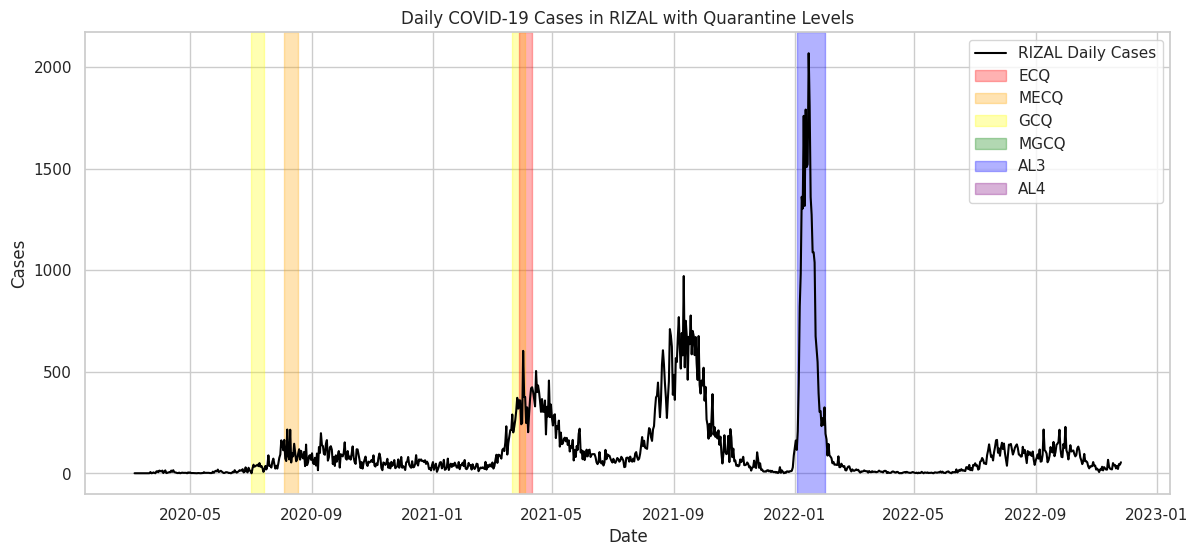

In [96]:
area_to_plot = 'RIZAL'

data = combined_daily[combined_daily['Location'] == area_to_plot]

plt.figure(figsize=(14,6))
plt.plot(data['DateRepConf'], data['Cases'], color='black', label=f'{area_to_plot} Daily Cases')

for i, row in timeline_df.iterrows():
    if row['Region/Province/City'] == area_to_plot:
        plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.3)

legend_patches = [mplp.Patch(color=color, alpha=0.3, label=label) for label, color in colors.items()]
daily_cases = Line2D([0], [0], color='black', linestyle='-', label=f'{area_to_plot} Daily Cases')

plt.title(f'Daily COVID-19 Cases in {area_to_plot} with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(handles=[daily_cases] + legend_patches)
plt.show()

Rizal stayed low during 2020 and only reached about a 250 cases in one day where they began implementation of MECQ. In 2021, the implementation of ECQ coincided almost exactly with the hike during March-April. Alert Level 3 was implemented during the beginning of the new year because of the sudden hike.

###### Cavite

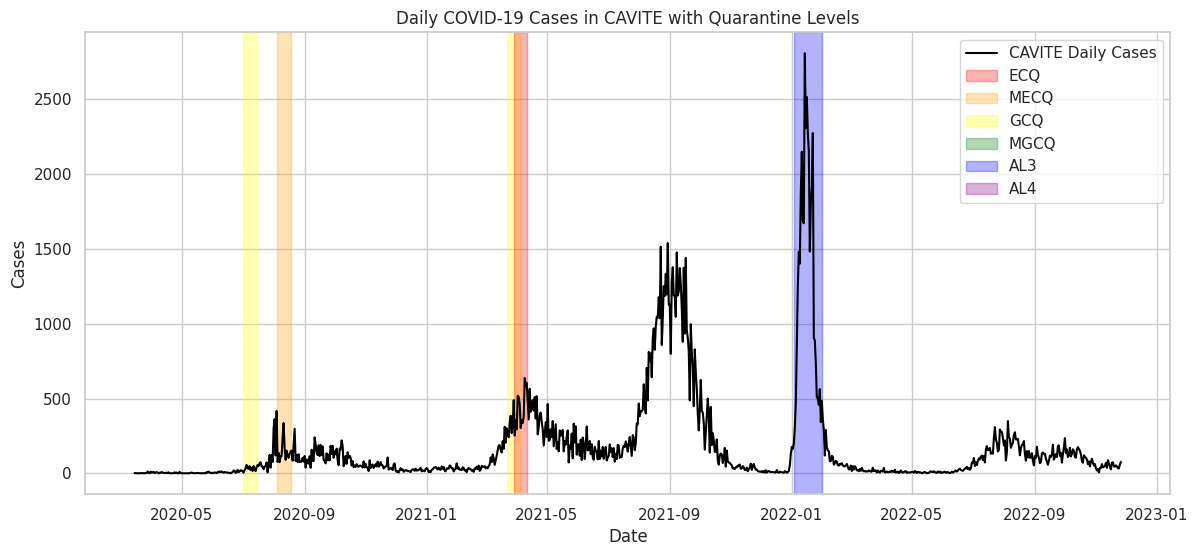

In [97]:
area_to_plot = 'CAVITE'

data = combined_daily[combined_daily['Location'] == area_to_plot]

plt.figure(figsize=(14,6))
plt.plot(data['DateRepConf'], data['Cases'], color='black', label=f'{area_to_plot} Daily Cases')

for i, row in timeline_df.iterrows():
    if row['Region/Province/City'] == area_to_plot:
        plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.3)

legend_patches = [mplp.Patch(color=color, alpha=0.3, label=label) for label, color in colors.items()]
daily_cases = Line2D([0], [0], color='black', linestyle='-', label=f'{area_to_plot} Daily Cases')

plt.title(f'Daily COVID-19 Cases in {area_to_plot} with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(handles=[daily_cases] + legend_patches)
plt.show()

COVID-19 cases slowly began rising during July-August of 2020 where they implemented GCQ during the period with lesser cases and MECQ when cases immediately hiked to almost 500 in a day. Cases remained low after that and began hiking again during the first quarter of 2021, where they implemented the first ECQ. Alert Level 3 was implemented in a similar time frame as the others, during the new year period of 2022.

###### Combined

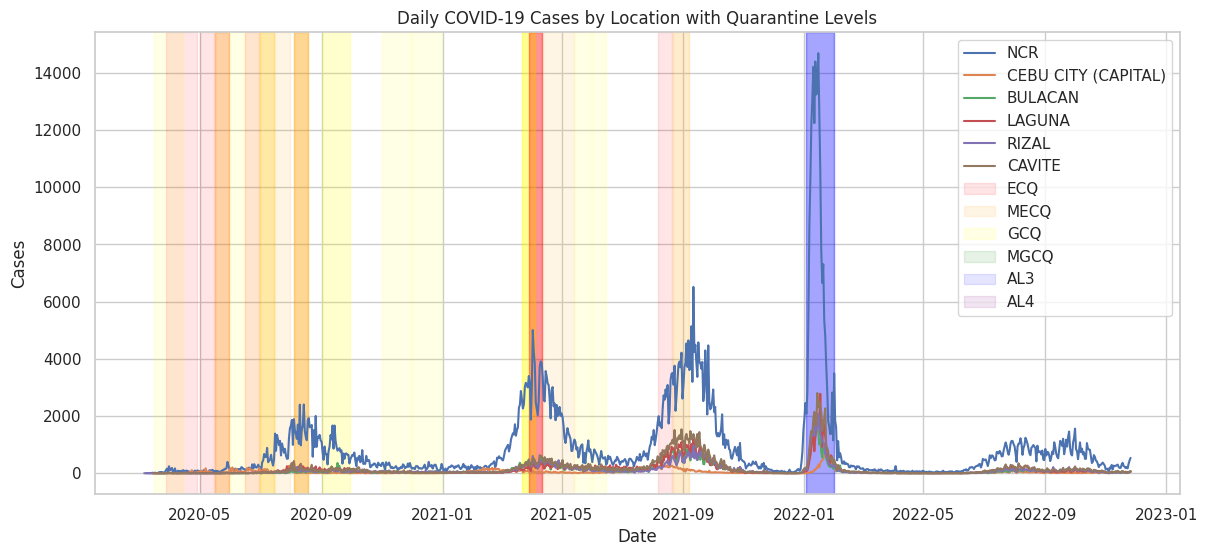

In [98]:
timeline_df['ProvRes_Mapped'] = timeline_df['Region/Province/City']
timeline_df.loc[timeline_df['Region/Province/City'] == 'CITY OF CEBU', 'ProvRes_Mapped'] = 'CEBU CITY (CAPITAL)'


area_to_plot = ['NCR', 'CEBU CITY (CAPITAL)', 'BULACAN', 'LAGUNA', 'RIZAL', 'CAVITE']

plt.figure(figsize=(14,6))

for area in area_to_plot:
    temp = combined_daily[combined_daily['Location'] == area]
    plt.plot(temp['DateRepConf'], temp['Cases'], label=area)

    for i, row in timeline_df.iterrows():
        if row['ProvRes_Mapped'] == area:
            plt.axvspan(row['Start Date'], row['End Date'], color=colors.get(row['QuarantineCode'], 'gray'), alpha=0.1)

legend_patches = [mplp.Patch(color=color, alpha=0.1, label=label) for label, color in colors.items()]

plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + legend_patches,
           labels=[label for label in area_to_plot] + list(colors.keys()))

plt.title('Daily COVID-19 Cases by Location with Quarantine Levels')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

Looking at the aggregated graph that contains all locations and their quarantine levels, we could say that most of their peaks are of similar ratio to each other, with NCR reaching the highest number of cases, as it is the most populated and dense.

The Community Quarantine periods were implemented multiple times during the first half of 2020, when COVID-19 was new, to prevent the spread of the virus.

Stricter quarantine levels (ECQ/MECQ) coincide with the absolute peaks of the cases for those specific time periods, acting as a reactive "ceiling" that forced the numbers to eventually die down after a short lag, while more relaxed levels (GCQ/MGCQ) often allowed for the build-up of subsequent cases.


# AI Declaration

- Statement: During the preparation of this work the author(s) used gemini for the following purposes:

- Webscrapper for gathering data for provincial rankings and city-wide scores from https://cmci.dti.gov.ph/

- After using this tool/service, the authors(s) reviewed and edited the content as needed and take(s) full responsibility for the content of the publication.